In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
)

Гипотезы:
1. Из-за дисбаланса классов accuracy будет неинформативной, f1 и average precision будут полезнее
   Взял Average precision за основу, accuracy у разных моделей слабо различается, ансамблевые методы дают значительный рост AP (примерно на 10%), но при этом Accuracy меняется всего на 3%.
2. Elastic Net обойдёт OLS из-за большого количества лишних колонок.
   Результат: регуляризация не помогла
3. Из-за дисбаланса классов линейная регрессия будет работать плохо -- будет сильное смещение в сторону предсказания доминирующего класса
   Так и получается, AP у LogReg гораздо меньше чем у ансамблевых методов.
4. Ансамблевые методы будут работать лучше линейной регрессии, так как есть сильный дисбаланс классов.
   Подтвердилось, RandomForest и GradientBoosting даже без настройки побеждают LogReg
5. При отборе признаков и оставлении не более чем 5 признаков качество предсказания не ухудшится
   Частично подтвердилось: случайному лесу достаточно 8 признаков, градиентному бустинге достаточно 7, дальше рост метрик если и есть, то он меньше погрешности определения величин.


# 1. Загрузка данных

In [2]:
df=pd.read_csv('C:/Users/Alex/Anaconda_progs/ML2026/Homeworks/HW1/online_shoppers_intention.csv')

In [3]:
target_col='Revenue'

# 2. Анализ данных

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  

### Распределение классов (целевая переменная $Y$)

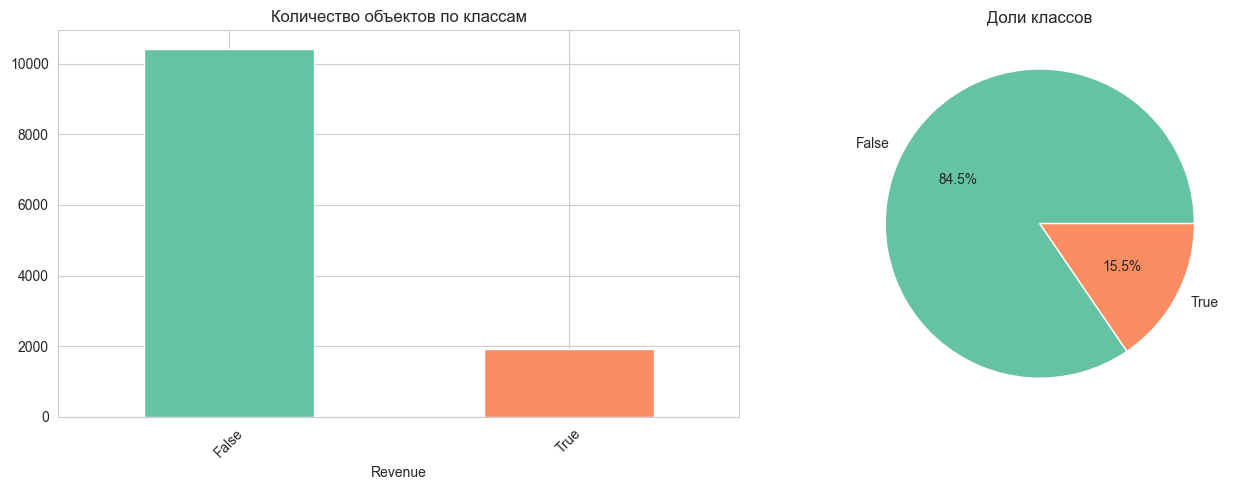

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

### Распределения признаков $x_1, x_2, \ldots, x_d$

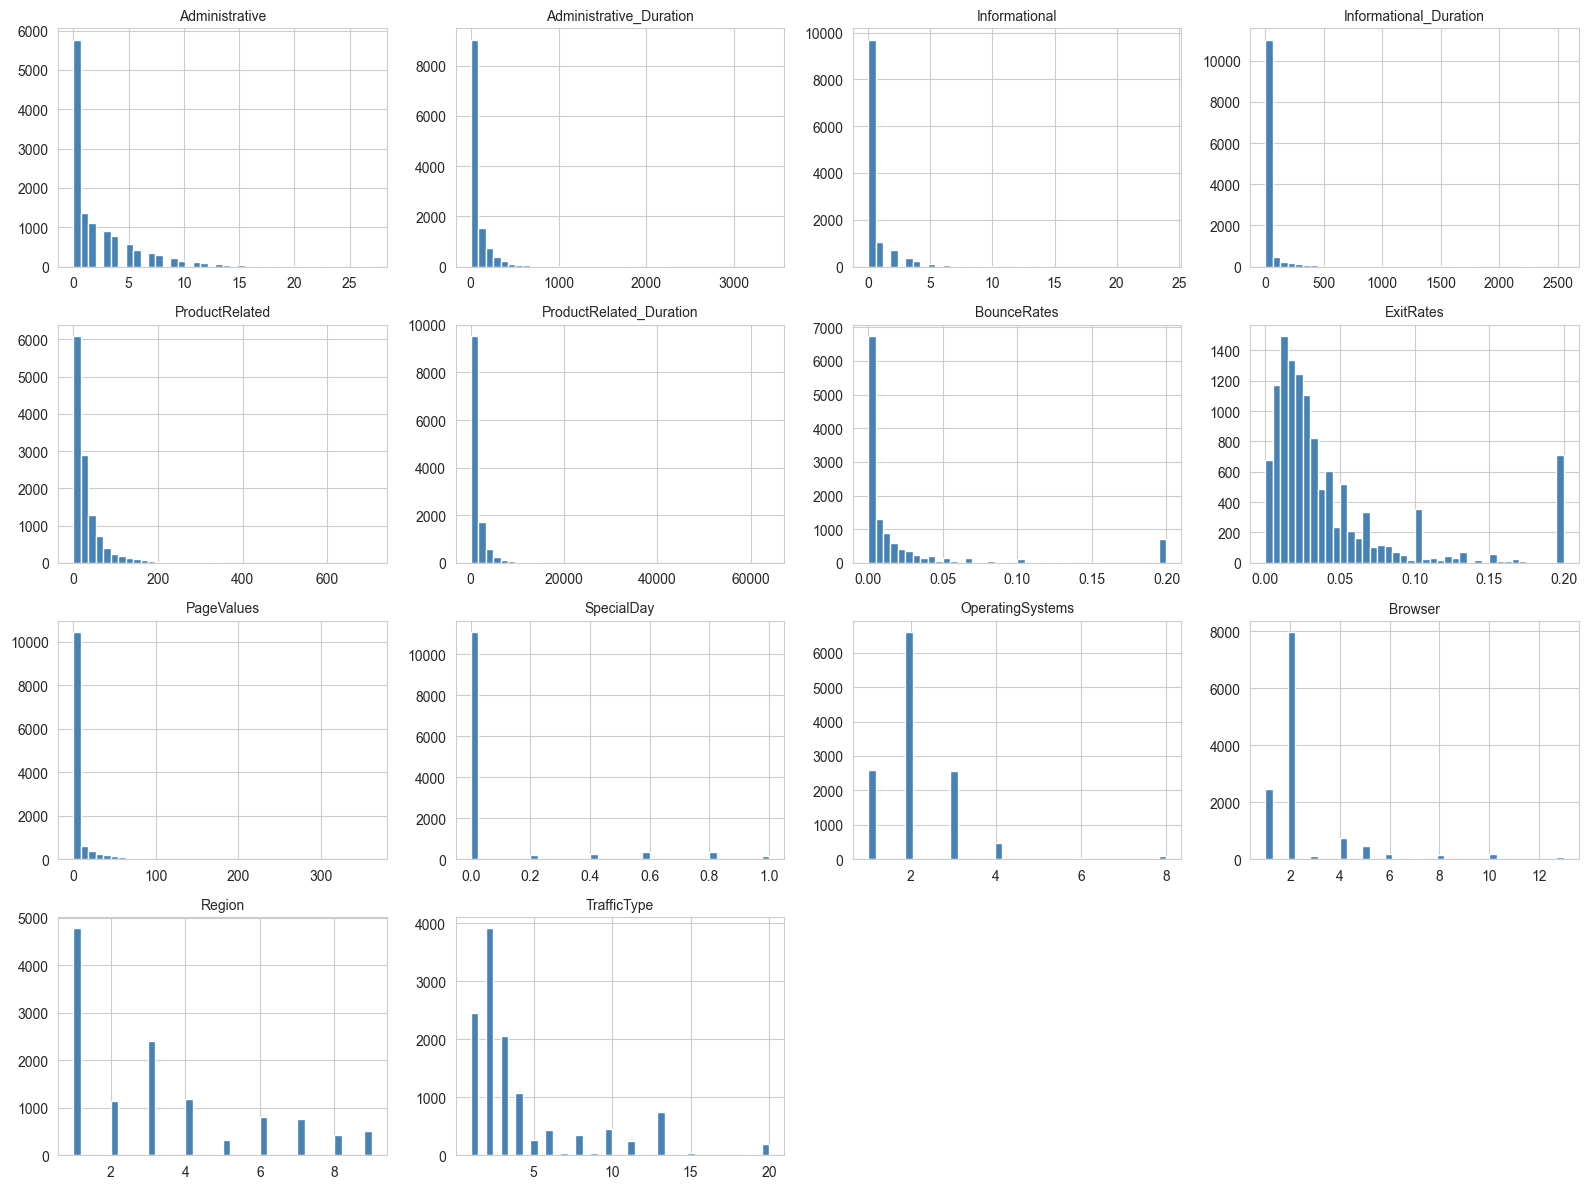

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Корреляционная матрица

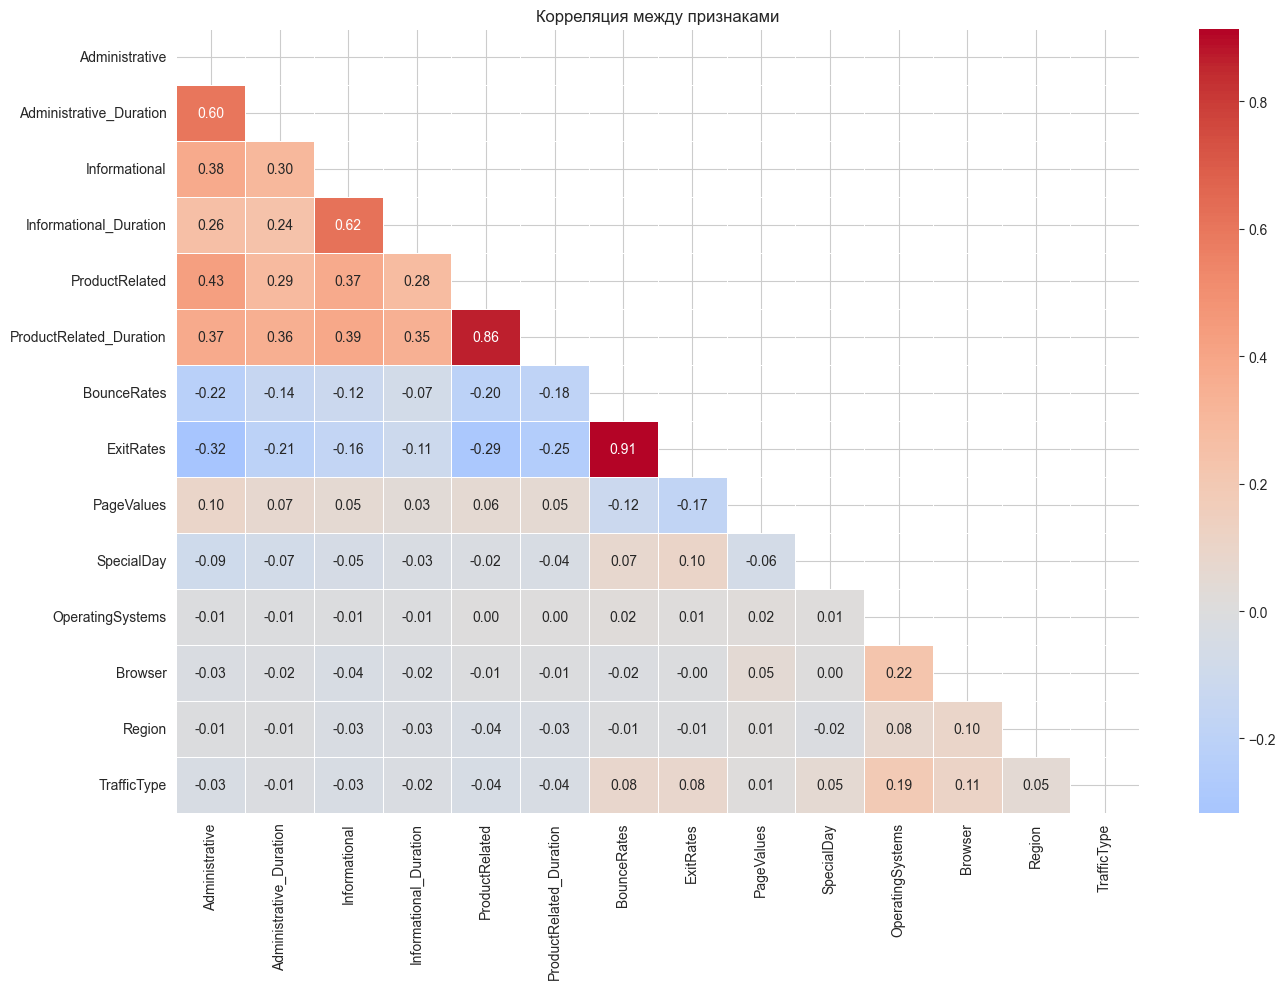

In [11]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

### Boxplot признаков по классам

In [12]:
cols_all=df

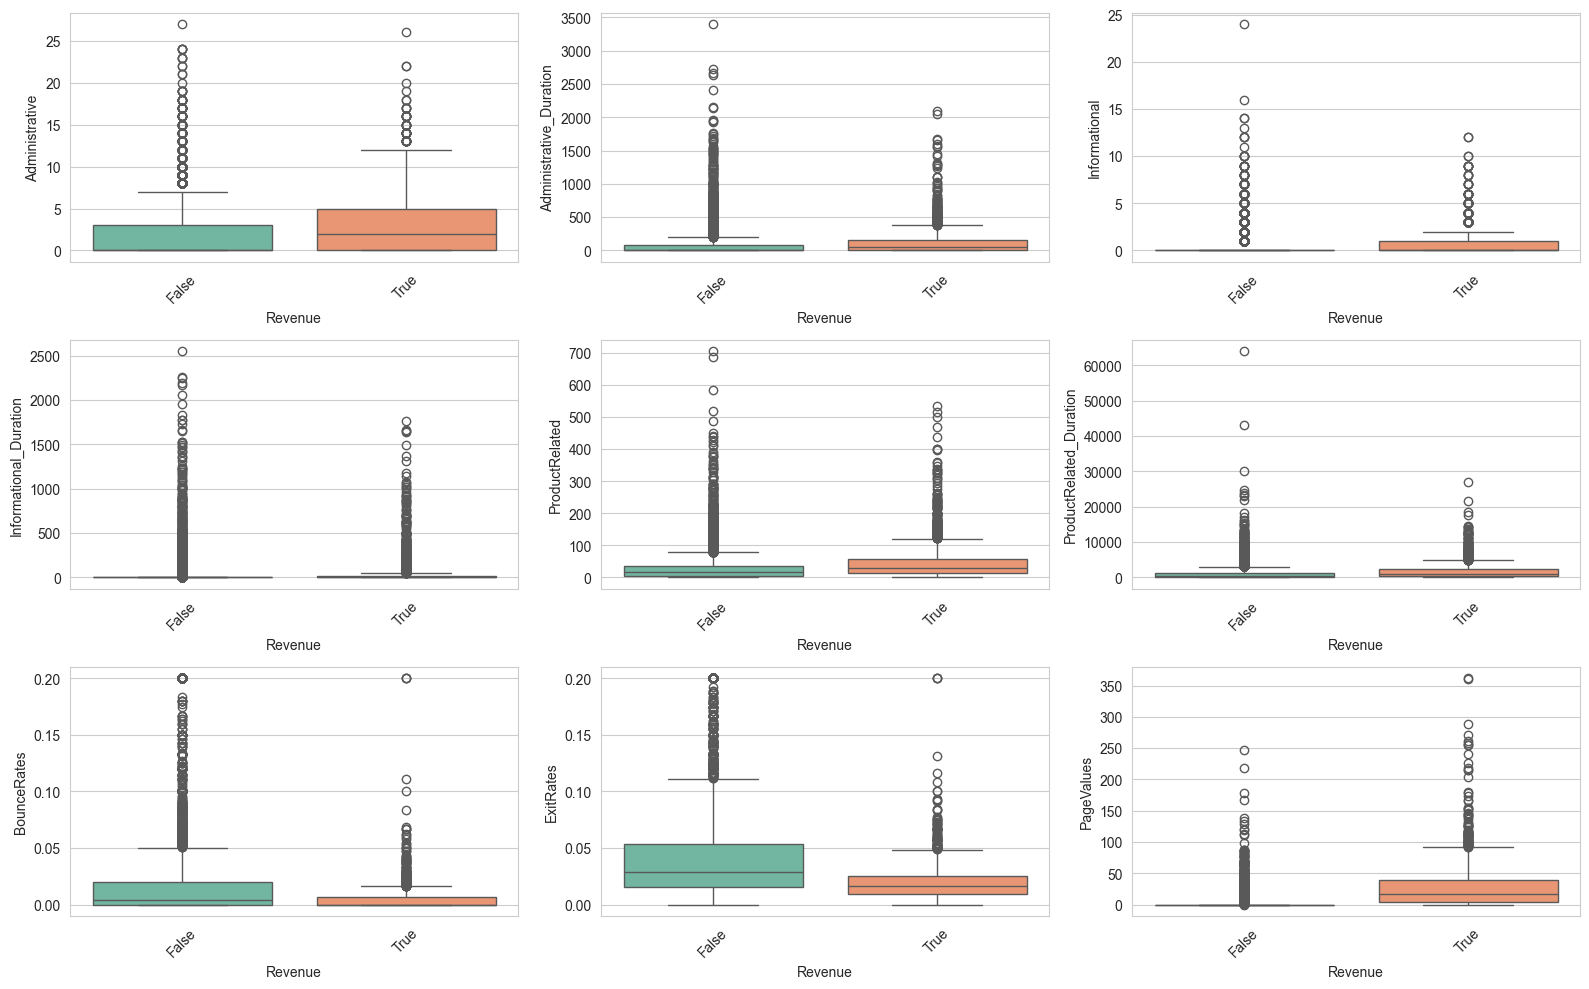

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for idx, col in enumerate(numeric_cols[:9]):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

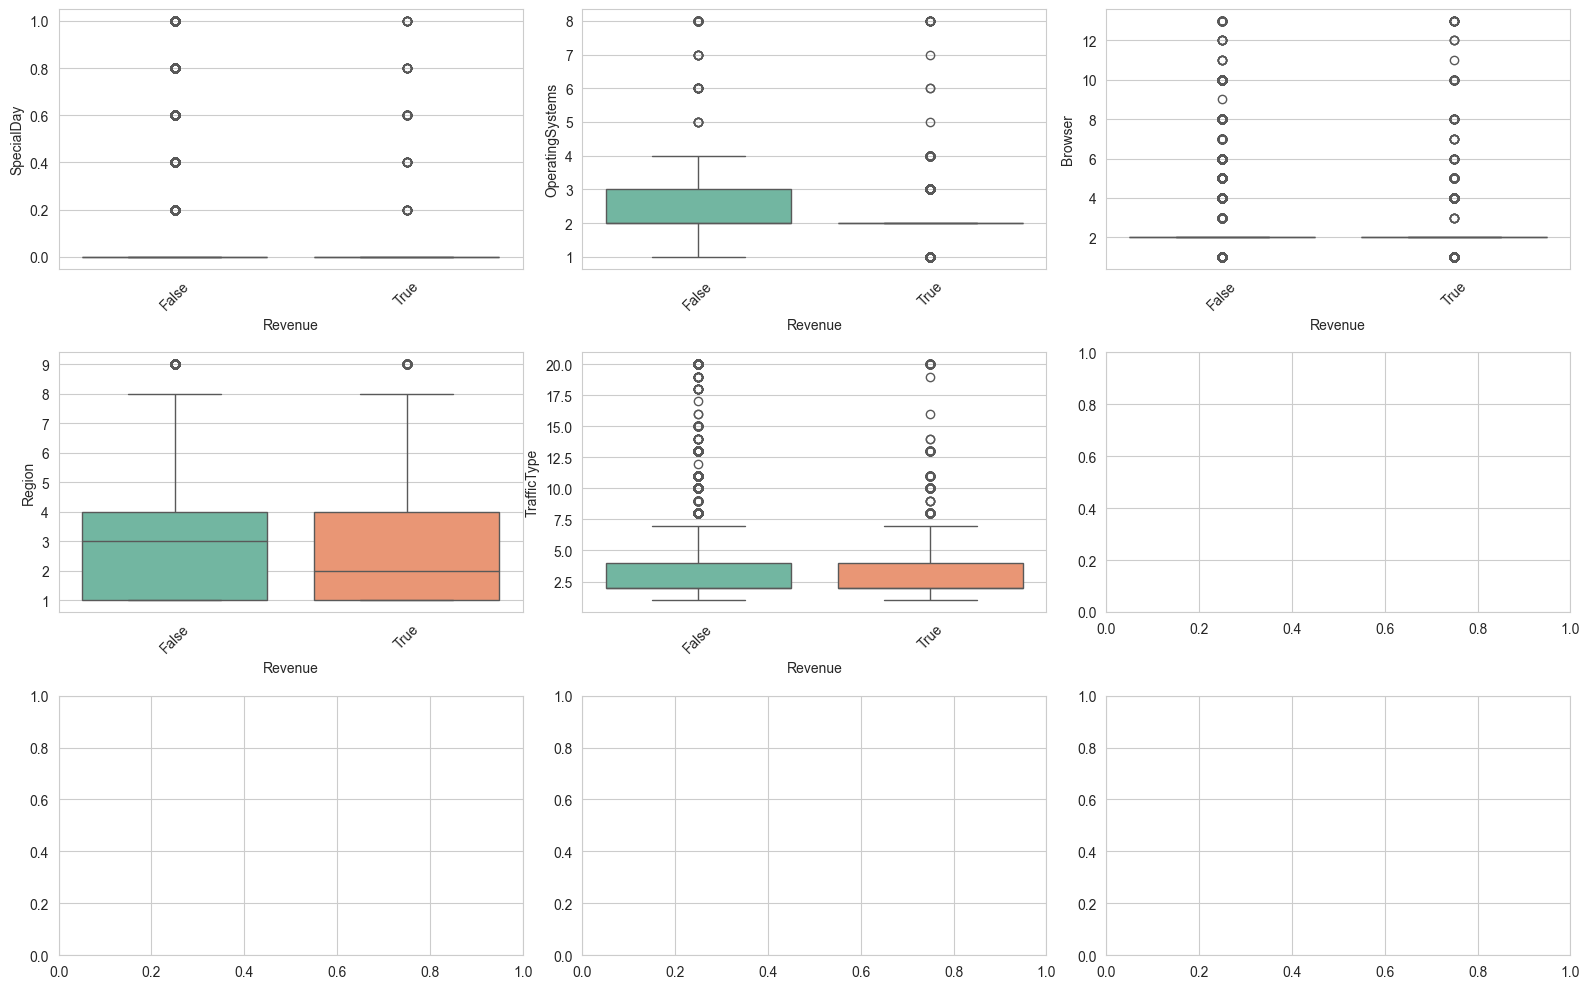

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for idx, col in enumerate(numeric_cols[9:]):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [15]:
from copy import deepcopy

In [16]:
key_cols = deepcopy(numeric_cols)
key_cols.append(target_col)

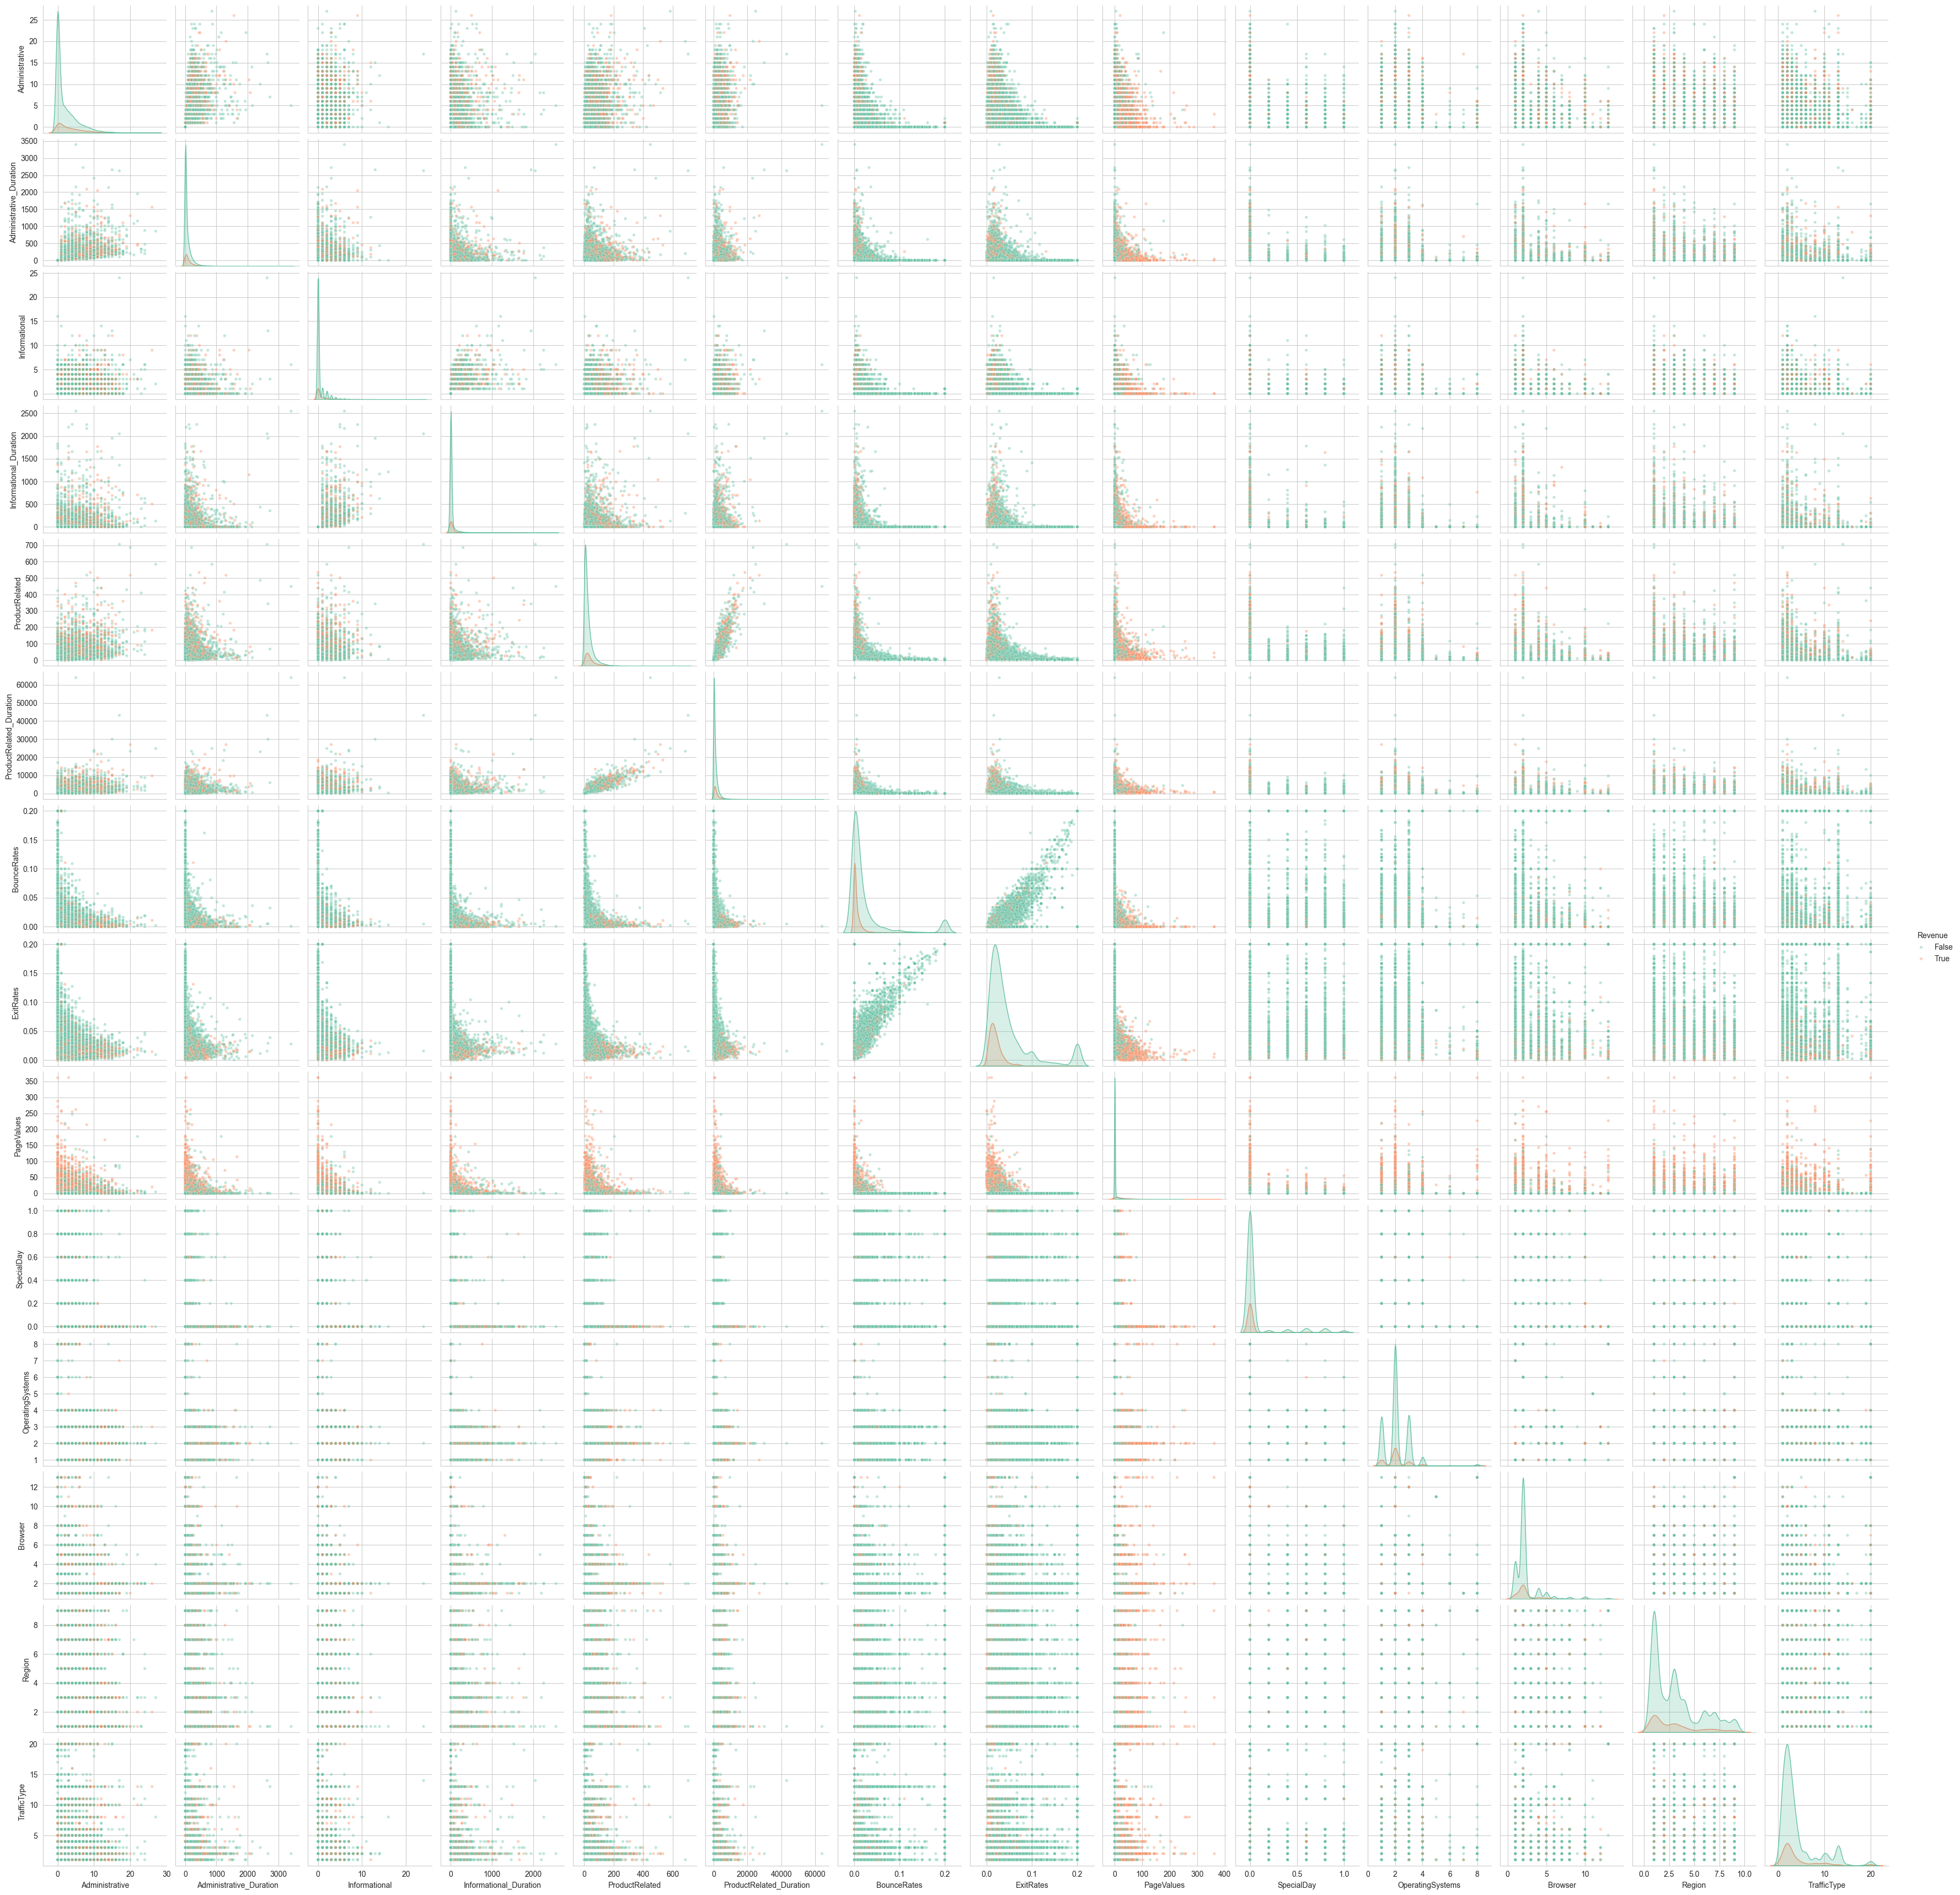

In [18]:
sns.pairplot(df[key_cols],
             hue=target_col, palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

Пропусков в данных (Null) нет. Сильный дисбаланс в выборке. Сильных корреляций в признаках как будто бы почти нет, за исключением 2 пар с похожими названиями.

# 3.Подготовка данных

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder



target_col='Revenue'
X_all = df.drop(columns=target_col).copy()

y_all = LabelEncoder().fit_transform( df[target_col])
X_train_val, X_test, y_train_val, y_test =  train_test_split(X_all, y_all, test_size=0.2, random_state=123, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=123, stratify=y_train_val)



In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "June": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train["Month"] = X_train["Month"].map(month_map)
X_val["Month"] = X_val["Month"].map(month_map)
X_test["Month"] = X_test["Month"].map(month_map)

cat_cols = X_train.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()

num_cols = [
    col for col in X_train.select_dtypes(include="number").columns
    if col != "Month"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), cat_cols),
    ("month", "passthrough", ["Month"])
])
preprocessor.set_output(transform="pandas")

X_train_sc = preprocessor.fit_transform(X_train)
X_val_sc = preprocessor.transform(X_val)
X_test_sc = preprocessor.transform(X_test)

In [19]:
X_train_sc.head()

,num__Administrative,num__Administrative_Duration,num__Informational,num__Informational_Duration,num__ProductRelated,num__ProductRelated_Duration,num__BounceRates,num__ExitRates,num__PageValues,num__SpecialDay,num__OperatingSystems,num__Browser,num__Region,num__TrafficType,cat__VisitorType_New_Visitor,cat__VisitorType_Other,cat__VisitorType_Returning_Visitor,cat__Weekend_False,cat__Weekend_True,month__Month
10159,-0.398832,-0.381724,0.396712,-0.250264,3.766111,3.876030,-0.367739,-0.519674,-0.117712,-0.306616,-0.142356,1.548236,0.344836,-0.762404,0.0,0.0,1.0,1.0,0.0,11
12112,-0.398832,-0.403728,-0.392014,-0.250264,-0.040037,-0.321881,-0.253574,-0.575609,-0.319713,-0.306616,-0.142356,-0.214189,-0.485021,1.489704,0.0,0.0,1.0,1.0,0.0,12
11966,-0.398832,-0.228657,1.185438,9.840469,0.542080,0.202564,-0.311619,-0.431383,1.205669,-0.306616,-0.142356,-0.214189,-0.899949,0.989235,0.0,0.0,1.0,0.0,1.0,11
10129,1.423683,-0.165516,-0.392014,-0.250264,0.609247,0.412148,-0.455571,-0.818832,-0.319713,-0.306616,-0.142356,-0.214189,-0.070092,-0.762404,0.0,0.0,1.0,1.0,0.0,12
9759,0.208673,0.015295,2.762891,1.320396,1.661535,0.965813,-0.347758,-0.460467,0.710997,-0.306616,-0.142356,-0.214189,1.589621,-0.512170,0.0,0.0,1.0,1.0,0.0,11


In [20]:
y_train.shape

(7891,)

# 4. Логистическая регрессия

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

log_reg_bin = LogisticRegression(max_iter=1000, random_state=1, class_weight='balanced').fit(X_train_sc, y_train)
y_pred_bin = log_reg_bin.predict(X_val_sc)
y_proba_bin = log_reg_bin.predict_proba(X_val_sc)[:, 1]

f1_score(y_val, y_pred_bin)


0.6180257510729614

### 4.1 Confusion Matrix

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

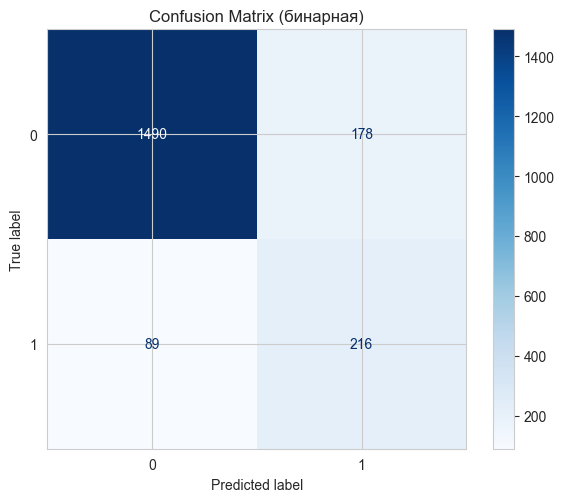

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_bin, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix (бинарная)')
plt.tight_layout()
plt.show()

### 4.2 Precision, Recall, F1, Log-Loss

$\text{Precision} = \frac{TP}{TP+FP}$, $\text{Recall} = \frac{TP}{TP+FN}$, $F_1 = 2\frac{P \cdot R}{P+R}$

In [23]:
pd.DataFrame({
    'Accuracy': [accuracy_score(y_val, y_pred_bin)],
    'Precision': [precision_score(y_val, y_pred_bin)],
    'Recall': [recall_score(y_val, y_pred_bin)],
    'F1': [f1_score(y_val, y_pred_bin)],
    'Log-Loss': [log_loss(y_val, y_proba_bin)],
    'ROC-AUC': [roc_auc_score(y_val, y_proba_bin)],
    'Average precision': [average_precision_score(y_val, y_proba_bin)]
}, index=['LogReg (binary)']).round(4)

,Accuracy,Precision,Recall,F1,Log-Loss,ROC-AUC,Average precision
LogReg (binary),0.8647,0.5482,0.7082,0.618,0.4375,0.8929,0.6303


### 4.3 ROC-кривая и PR-кривая

**ROC:** TPR vs FPR при разных порогах $\tau$. AUC = 0.5 для случайной модели.

**PR:** Precision vs Recall — лучше при несбалансированных классах.

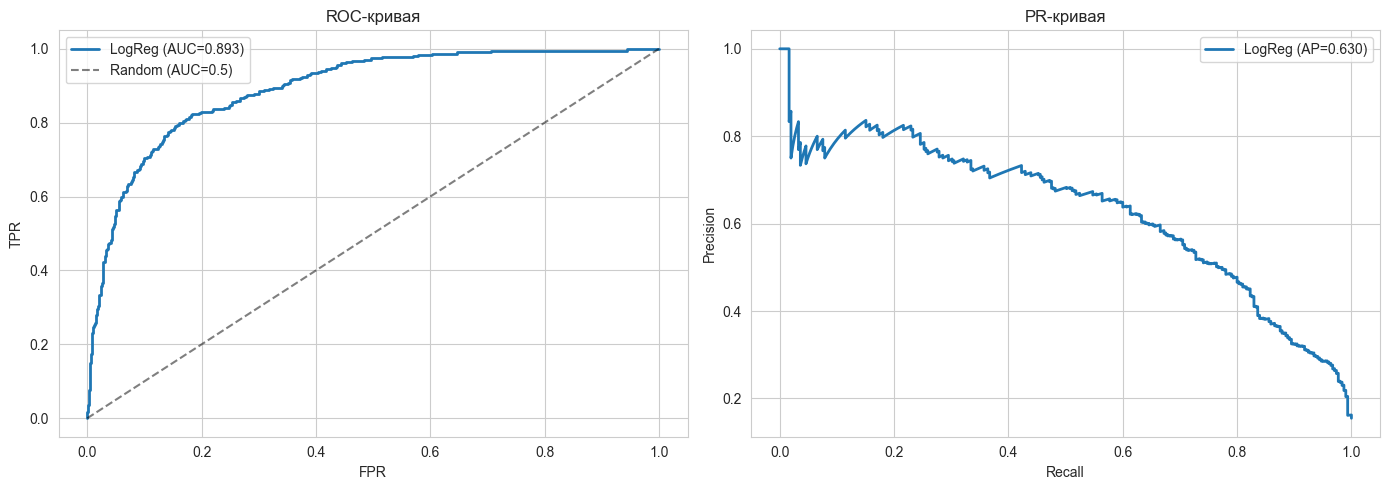

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_val, y_proba_bin)
axes[0].plot(fpr, tpr, linewidth=2, label=f'LogReg (AUC={roc_auc_score(y_val, y_proba_bin):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_val, y_proba_bin)
ap = average_precision_score(y_val, y_proba_bin)
axes[1].plot(rec, prec, linewidth=2, label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.4 Влияние порога $\tau$ на метрики

$\hat{y} = \mathbb{I}[P(y=1|x) > \tau]$

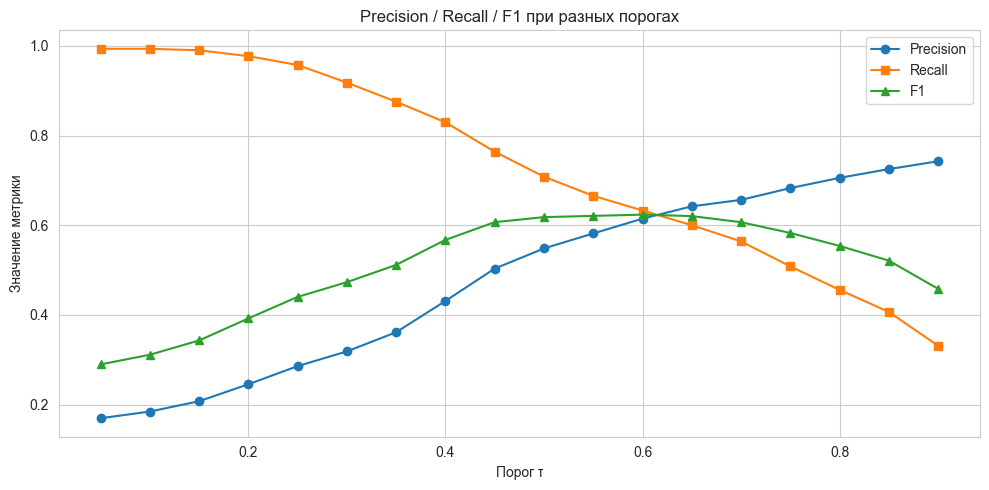

In [25]:
thresholds = np.arange(0.05, 0.95, 0.05)
metrics_by_t = []
for t in thresholds:
    y_t = (y_proba_bin >= t).astype(int)
    metrics_by_t.append({
        'threshold': t,
        'precision': precision_score(y_val, y_t, zero_division=0),
        'recall': recall_score(y_val, y_t, zero_division=0),
        'f1': f1_score(y_val, y_t, zero_division=0),
    })
df_t = pd.DataFrame(metrics_by_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
ax.set_xlabel('Порог τ')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F1 при разных порогах')
ax.legend()
plt.tight_layout()
plt.show()

### 4.5 Выбор оптимального порога и `class_weight`

Порог 0.5 не оптимален при дисбалансе. Найдём $\tau^*$, максимизирующий F1, и сравним с моделью `class_weight='balanced'`.

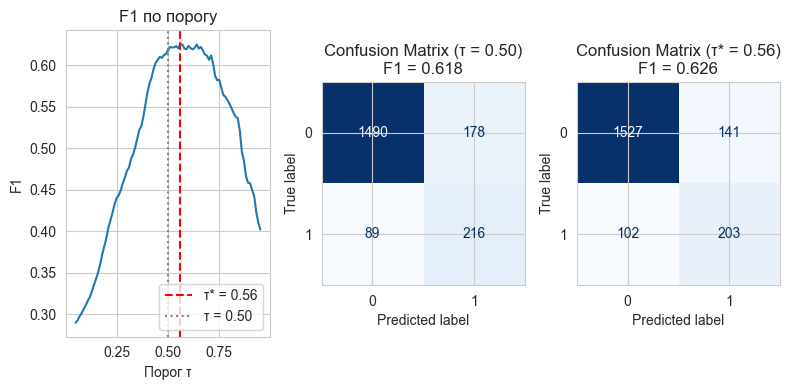

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

taus = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (y_proba_bin >= t).astype(int)) for t in taus]

precisions = [precision_score(y_val, (y_proba_bin >= t).astype(int)) for t in taus]
tau_star = taus[int(np.argmax(f1s))]


fig, axes = plt.subplots(1, 3, figsize=(8, 4))
axes[0].plot(taus, f1s)
axes[0].axvline(tau_star, color='red', ls='--', label=f'τ* = {tau_star:.2f}')
axes[0].axvline(0.5, color='gray', ls=':', label='τ = 0.50')
axes[0].set_xlabel('Порог τ'); axes[0].set_ylabel('F1'); axes[0].set_title('F1 по порогу'); axes[0].legend()
for ax, t, name in [(axes[1], 0.5, 'τ = 0.50'), (axes[2], tau_star, f'τ* = {tau_star:.2f}')]:
    cm = confusion_matrix(y_val, (y_proba_bin >= t).astype(int))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
    f1v = f1_score(y_val, (y_proba_bin >= t).astype(int))
    ax.set_title(f'Confusion Matrix ({name})\nF1 = {f1v:.3f}')
plt.tight_layout(); plt.show()

In [27]:
log_reg_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1).fit(X_train_sc, y_train)
y_pred_bal = log_reg_bal.predict(X_val_sc)
y_proba_bal = log_reg_bal.predict_proba(X_val_sc)[:, 1]

def _row(pred, proba):
    return [precision_score(y_val, pred), recall_score(y_val, pred),
            f1_score(y_val, pred), roc_auc_score(y_val, proba), average_precision_score(y_val, proba)]

pd.DataFrame(
    [_row(y_pred_bin, y_proba_bin),
     _row((y_proba_bin >= tau_star).astype(int), y_proba_bin),
     _row(log_reg_bal.predict(X_val_sc), y_proba_bal)],
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'Average Precision'],
    index=['LogReg τ=0.5', 'LogReg τ*', "LogReg class_weight='balanced'"]).round(4)

,Precision,Recall,F1,ROC-AUC,Average Precision
LogReg τ=0.5,0.5482,0.7082,0.6180,0.8929,0.6303
LogReg τ*,0.5901,0.6656,0.6256,0.8929,0.6303
LogReg class_weight='balanced',0.5482,0.7082,0.6180,0.8929,0.6303


### 4.6 Калибровка вероятностей

Насколько предсказанные вероятности соответствуют реальной частоте положительного класса (reliability diagram).

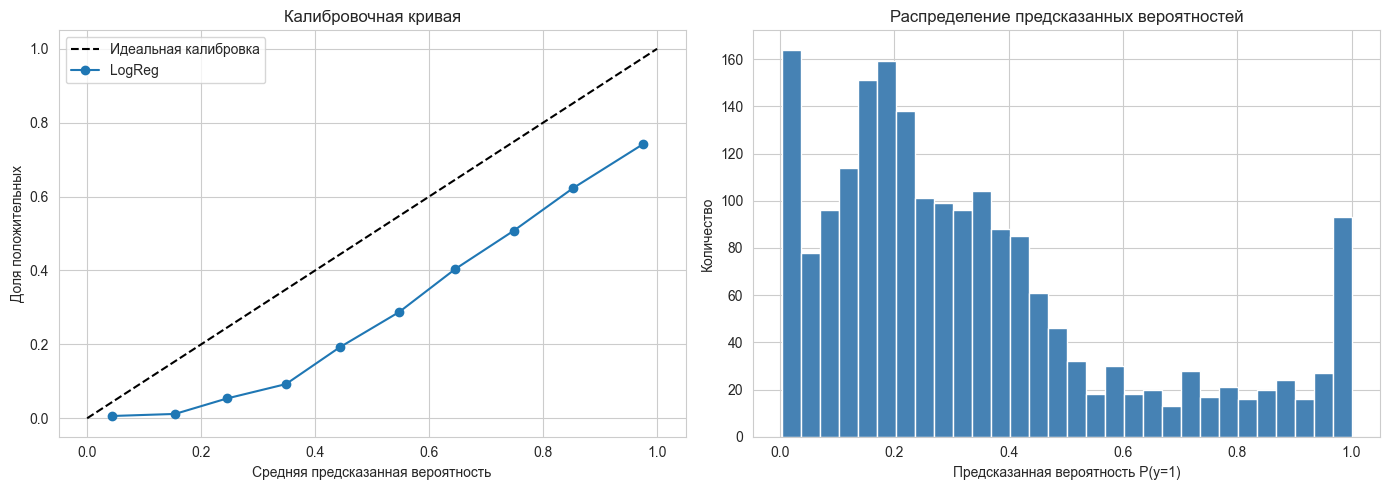

In [28]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_val, y_proba_bin, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
axes[0].plot(prob_pred, prob_true, 'o-', label='LogReg')
axes[0].set_xlabel('Средняя предсказанная вероятность'); axes[0].set_ylabel('Доля положительных')
axes[0].set_title('Калибровочная кривая'); axes[0].legend()
axes[1].hist(y_proba_bin, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Предсказанная вероятность P(y=1)'); axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение предсказанных вероятностей')
plt.tight_layout(); plt.show()

## 4.7 Подбор гиперпараметров регрессии

In [29]:
import sklearn
from packaging.version import Version

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# clone сохраняет настройки preprocessor, но убирает обученное состояние
pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(
        solver="saga",
        class_weight="balanced",
        max_iter=10000,
        random_state=123,
    )),
])

# Сетка силы регуляризации: меньше C → сильнее регуляризация
param_grid = {
    "model__C": np.logspace(-9, 3, 17),
}


param_grid = [
    {
        "model__penalty": ["l1", "l2"],
        "model__C": np.logspace(-4, 3, 8),
    },
    {
        "model__penalty": ["elasticnet"],
        "model__C": np.logspace(-4, 3, 8),
        "model__l1_ratio": np.linspace(0.01,0.99,11),
    },
    {
        # Именно None, а не строка "none" (sklearn >= 1.2)
        "model__penalty": [None],
    },
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123,
)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={

        "average_precision": "average_precision",
        "f1": "f1",
        "roc_auc": "roc_auc",
    },
    refit="average_precision",             # Выбираем лучшую модель по average precision
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    error_score="raise",
)

# Только train: тестовая выборка не участвует в подборе
search.fit(X_train, y_train)

print("Лучшие параметры:", search.best_params_)
print(f"Средний AP на кросс-валидации: {search.best_score_:.4f}")

Лучшие параметры: {'model__C': np.float64(0.01), 'model__penalty': 'l1'}
Средний AP на кросс-валидации: 0.6378


In [30]:
results = pd.DataFrame(search.cv_results_)

def describe_params(params):
    penalty = params.get("model__penalty", "not_specified")
    C = params.get("model__C", 1.0)

    if penalty is None or np.isinf(C):
        return "Без регуляризации", np.nan, np.nan

    ratio = params.get("model__l1_ratio")

    if penalty == "l1":
        ratio = 1.0
    elif penalty == "l2":
        ratio = 0.0

    if ratio == 0.0:
        name = "L2"
    elif ratio == 1.0:
        name = "L1"
    else:
        name = "Elastic Net"

    return name, C, ratio


comparison = pd.DataFrame(
    results["params"].map(describe_params).tolist(),
    columns=["regularization", "C", "l1_ratio"],
)

metric_columns = {
    "mean_train_f1": "F1_train",
    "mean_test_f1": "F1_cv",
    "std_test_f1": "F1_cv_std",
    "mean_test_average_precision": "AP_cv",
    "mean_test_roc_auc": "ROC_AUC_cv",
}

for source, target in metric_columns.items():
    comparison[target] = results[source]

# with pd.option_context("display.max_rows", None, "display.max_columns", None):
#     display(comparison.sort_values("F1_cv", ascending=False).round(4))

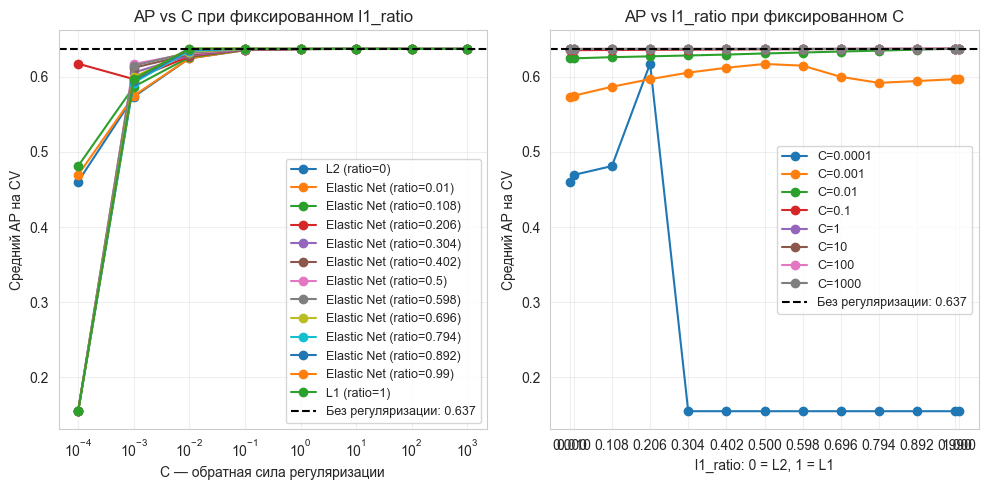

In [31]:
# Регуляризованные модели: конечные C и заданный l1_ratio
plot_data = comparison.dropna(subset=["C", "l1_ratio"]).copy()

baseline = comparison.loc[
    comparison["regularization"].eq("Без регуляризации"), "AP_cv"
]
baseline_f1 = baseline.iloc[0] if not baseline.empty else None

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 1. F1 vs C: отдельная линия для каждого l1_ratio
for ratio, group in plot_data.groupby("l1_ratio"):
    group = group.sort_values("C")
    label = (
        "L2 (ratio=0)" if ratio == 0
        else "L1 (ratio=1)" if ratio == 1
        else f"Elastic Net (ratio={ratio:g})"
    )

    axes[0].plot(
        group["C"], group["AP_cv"],
        marker="o", label=label,
    )

axes[0].set_xscale("log")
axes[0].set_xlabel("C — обратная сила регуляризации")
axes[0].set_ylabel("Средний AP на CV")
axes[0].set_title("AP vs C при фиксированном l1_ratio")

# 2. F1 vs l1_ratio: отдельная линия для каждого C
for C, group in plot_data.groupby("C"):
    group = group.sort_values("l1_ratio")
    axes[1].plot(
        group["l1_ratio"], group["AP_cv"],
        marker="o", label=f"C={C:g}",
    )

axes[1].set_xticks(sorted(plot_data["l1_ratio"].unique()))
axes[1].set_xlabel("l1_ratio: 0 = L2, 1 = L1")
axes[1].set_ylabel("Средний AP на CV")
axes[1].set_title("AP vs l1_ratio при фиксированном C")

for ax in axes:
    if baseline_f1 is not None:
        ax.axhline(
            baseline_f1,
            color="black",
            linestyle="--",
            label=f"Без регуляризации: {baseline_f1:.3f}",
        )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

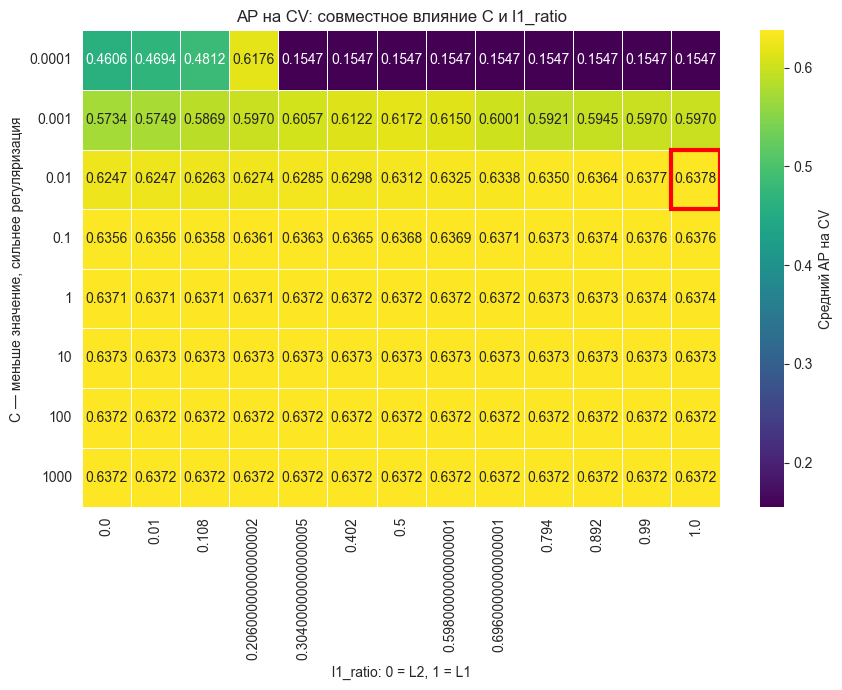

In [32]:
from matplotlib.patches import Rectangle

ap_grid = (
    plot_data.pivot(
        index="C",
        columns="l1_ratio",
        values="AP_cv",
    )
    .sort_index()
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    ap_grid,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Средний AP на CV"},
    ax=ax,
)

# Отмечаем максимальный F1
best_row, best_col = np.unravel_index(
    np.nanargmax(ap_grid.to_numpy()),
    ap_grid.shape,
)
ax.add_patch(Rectangle(
    (best_col, best_row),
    1, 1,
    fill=False,
    edgecolor="red",
    linewidth=3,
))

ax.set_yticklabels(
    [f"{C:g}" for C in ap_grid.index],
    rotation=0,
)
ax.set_xlabel("l1_ratio: 0 = L2, 1 = L1")
ax.set_ylabel("C — меньше значение, сильнее регуляризация")
ax.set_title("AP на CV: совместное влияние C и l1_ratio")

plt.tight_layout()
plt.show()

In [33]:
comparison

,regularization,C,l1_ratio,F1_train,F1_cv,F1_cv_std,AP_cv,ROC_AUC_cv
0,L1,0.0001,1.000,0.053608,0.053568,0.107135,0.154733,0.500000
1,L2,0.0001,0.000,0.434471,0.432183,0.013637,0.460564,0.812185
2,L1,0.0010,1.000,0.618676,0.617684,0.027201,0.596997,0.862789
3,L2,0.0010,0.000,0.569619,0.567333,0.024545,0.573430,0.874207
4,L1,0.0100,1.000,0.635407,0.632020,0.016119,0.637765,0.899914
...,...,...,...,...,...,...,...,...
100,Elastic Net,1000.0000,0.696,0.634514,0.629575,0.013696,0.637236,0.898351
101,Elastic Net,1000.0000,0.794,0.634514,0.629575,0.013696,0.637236,0.898351
102,Elastic Net,1000.0000,0.892,0.634514,0.629575,0.013696,0.637236,0.898351
103,Elastic Net,1000.0000,0.990,0.634514,0.629575,0.013696,0.637236,0.898351


## 4.8 Предсказание при лучшем наборе гиперпараметров

In [34]:


# Лучшие параметры уже выбраны поиском по CV
best_params = search.best_params_.copy()
print("Лучшие параметры:", best_params)

# clone сохраняет параметры лучшего pipeline, но убирает обучение
best_pipeline = clone(search.best_estimator_)

# 1. Получаем OOF-вероятности только на train
oof_proba = cross_val_predict(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# 2. Подбираем порог, максимизирующий F1 на OOF-предсказаниях
precision, recall, thresholds = precision_recall_curve(
    y_train, oof_proba
)

# Последняя пара precision/recall не имеет соответствующего порога
p = precision[:-1]
r = recall[:-1]

f1_by_threshold = np.divide(
    2 * p * r,
    p + r,
    out=np.zeros_like(p),
    where=(p + r) > 0,
)

best_threshold_idx = np.argmax(f1_by_threshold)
best_threshold = float(thresholds[best_threshold_idx])

print(f"Выбранный порог: {best_threshold:.4f}")
print(f"OOF F1 при подборе порога: {f1_by_threshold[best_threshold_idx]:.4f}")

# 3. Обучаем на всём train
final_model = clone(best_pipeline)
final_model.fit(X_train, y_train)

# 4. Применяем уже выбранный порог к отложенной валидации
val_proba = final_model.predict_proba(X_val)[:, 1]
val_pred = (val_proba >= best_threshold).astype(int)

Лучшие параметры: {'model__C': np.float64(0.01), 'model__penalty': 'l1'}
Выбранный порог: 0.5345
OOF F1 при подборе порога: 0.6376


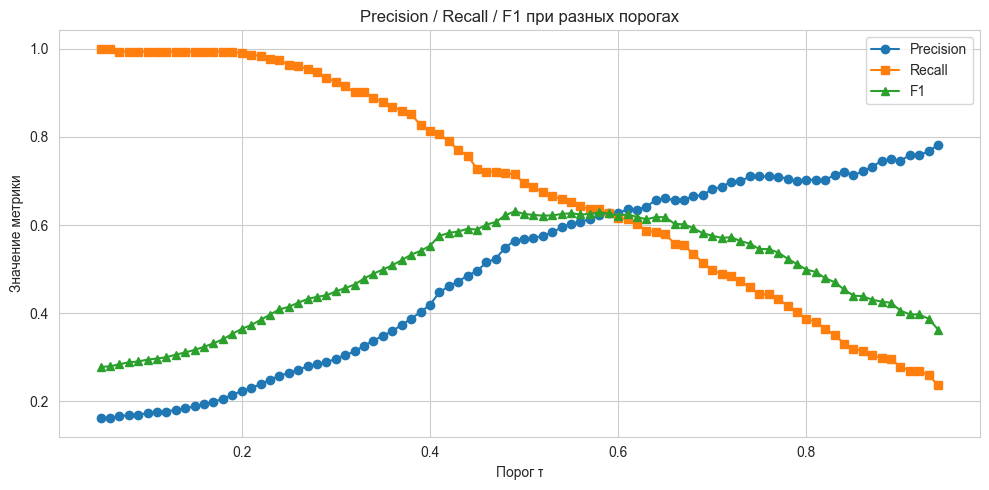

In [35]:
thresholds = np.arange(0.05, 0.95, 0.01)
metrics_by_t = []
for t in thresholds:
    y_t = (val_proba >= t).astype(int)
    metrics_by_t.append({
        'threshold': t,
        'precision': precision_score(y_val, y_t, zero_division=0),
        'recall': recall_score(y_val, y_t, zero_division=0),
        'f1': f1_score(y_val, y_t, zero_division=0),
    })
df_t = pd.DataFrame(metrics_by_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
ax.set_xlabel('Порог τ')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F1 при разных порогах')
ax.legend()
plt.tight_layout()
plt.show()

## 4.9 Словарь с лучшими результатами для каждого из методов

In [36]:
# Не очищаем результаты других методов при повторном запуске ячейки
if "model_results" not in globals():
    model_results = {}

method_name = "LogReg: CV + OOF threshold"

model_results[method_name] = {
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_params": best_params,
    "Best_estimator": final_model
}

results_table = (
    pd.DataFrame.from_dict(model_results, orient="index")
    .rename_axis("Method")
    .sort_values("AP", ascending=False)
)

display(results_table.round(4))

# Сохраняем таблицу между сессиями; путь относительно рабочей папки
results_table.to_csv(
    "model_comparison.csv",
    encoding="utf-8-sig",
)

,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,AP,LogLoss,Best_params,Best_estimator
Method,,,,,,,,,,
LogReg: CV + OOF threshold,0.5345,0.8748,0.5843,0.659,0.7722,0.8901,0.624,0.4386,"{'model__C': 0.01, 'model__penalty': 'l1'}","(ColumnTransformer(transformers=[('num', Stand..."


# 5. Дерево решений

## 5.1 Дерево и ансамбли

In [37]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

dt_cls = DecisionTreeClassifier(max_depth=2, random_state=2, criterion='gini')
dt_cls.fit(X_train_sc, y_train)
y_pred_dt = dt_cls.predict(X_val_sc)
y_proba_dt = dt_cls.predict_proba(X_val_sc)[:,1]
pd.DataFrame({
    "Average Precision": [average_precision_score(y_val, y_proba_dt)],
    "Accuracy": [accuracy_score(y_val, y_pred_dt)],
    "Precision": [precision_score(y_val, y_pred_dt)],
    "Recall": [recall_score(y_val, y_pred_dt)],
    "F1": [f1_score(y_val, y_pred_dt)],
    "ROC-AUC": [roc_auc_score(y_val, y_proba_dt)],
}, index=["DecisionTree (depth=5)"]).round(4)

,Average Precision,Accuracy,Precision,Recall,F1,ROC-AUC
DecisionTree (depth=5),0.5746,0.8951,0.7552,0.4754,0.5835,0.8782


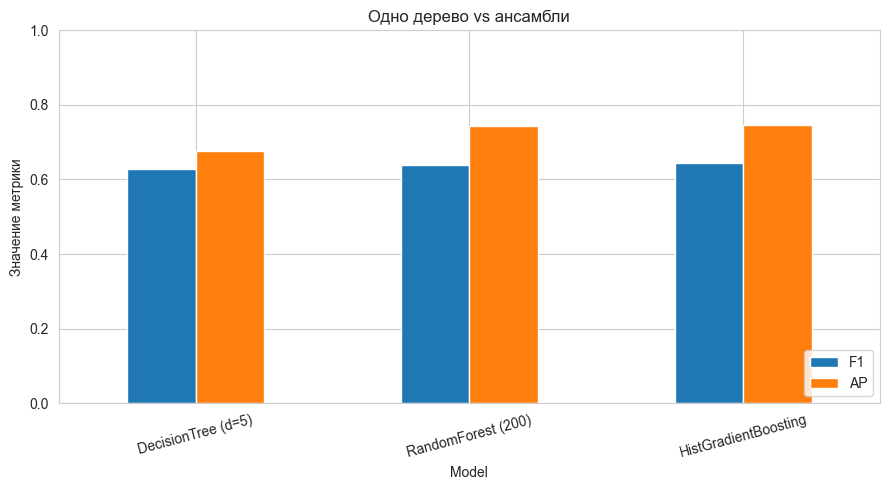

,F1,AP
Model,,
DecisionTree (d=5),0.6283,0.6767
RandomForest (200),0.6400,0.7441
HistGradientBoosting,0.6449,0.7462


In [38]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

ensemble_models = {
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_features = 'sqrt'),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
}
ens_res = []
for name, model in ensemble_models.items():
    model.fit(X_train_sc, y_train)
    yp = model.predict(X_val_sc)
    y_val_proba = model.predict_proba(X_val_sc)[:,1]
    ens_res.append({'Model': name, 
                    'F1': f1_score(y_val, yp), 'AP':average_precision_score(y_val, y_val_proba)})
df_ens = pd.DataFrame(ens_res).set_index('Model')

fig, ax = plt.subplots(figsize=(9, 5))
df_ens.plot.bar(ax=ax)
ax.set_ylim(0.0, 1.0); ax.set_ylabel('Значение метрики')
ax.set_title('Одно дерево vs ансамбли'); ax.tick_params(axis='x', rotation=15); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
df_ens.round(4)

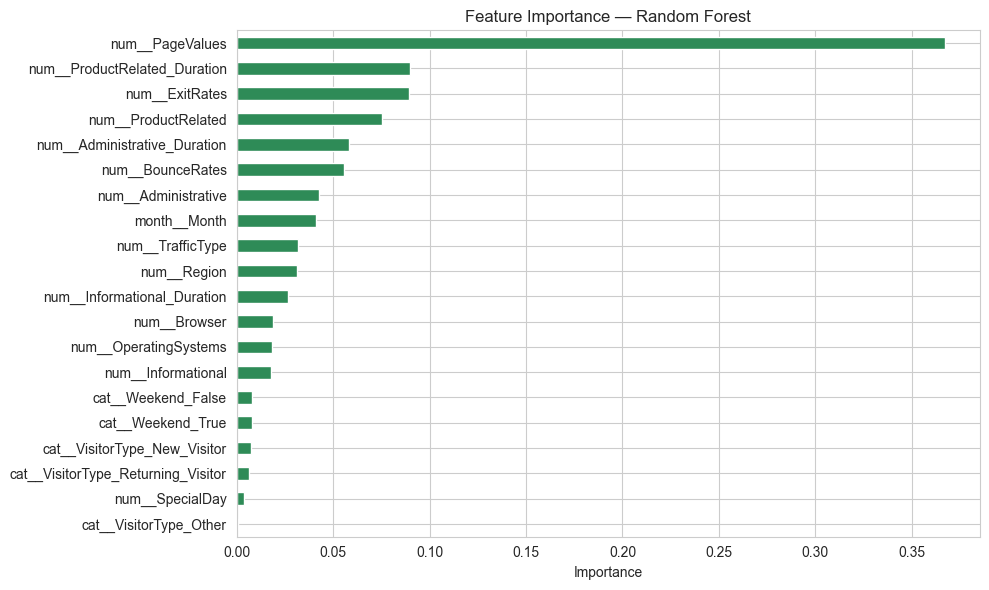

In [39]:
rf_imp = pd.Series(ensemble_models['RandomForest (200)'].feature_importances_,
                   index=X_train_sc.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
rf_imp.plot.barh(ax=ax, color='seagreen')
ax.set_title('Feature Importance — Random Forest'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 5.2 ROC and PR curves

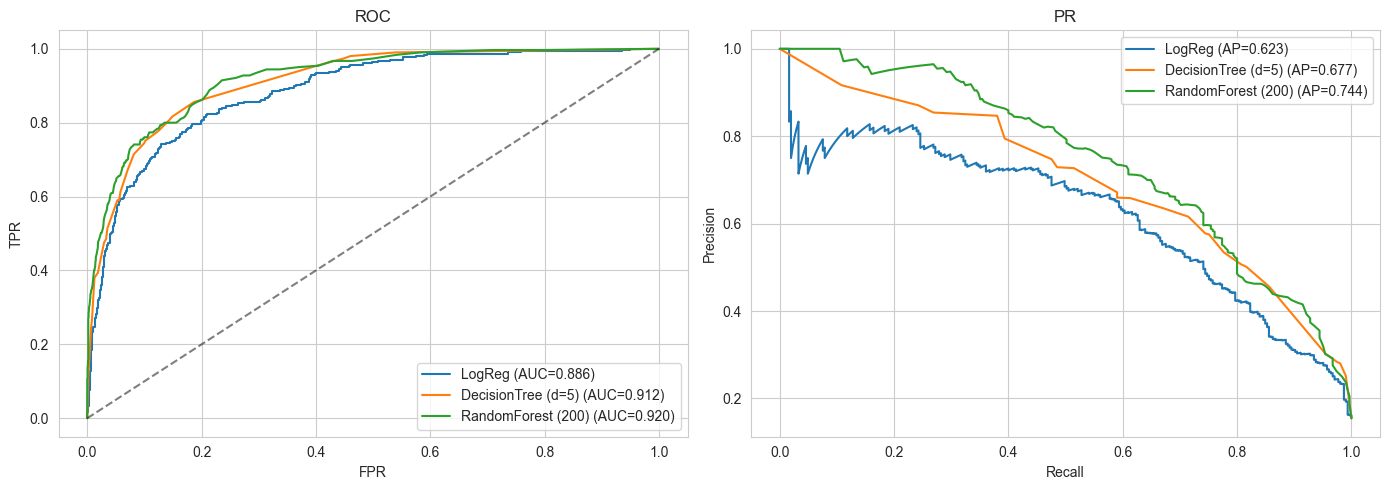

In [40]:
models_bin = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model in models_bin.items():
    model.fit(X_train_sc, y_train)
    proba = model.predict_proba(X_val_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_val, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR'); axes[1].legend()
plt.tight_layout(); plt.show()

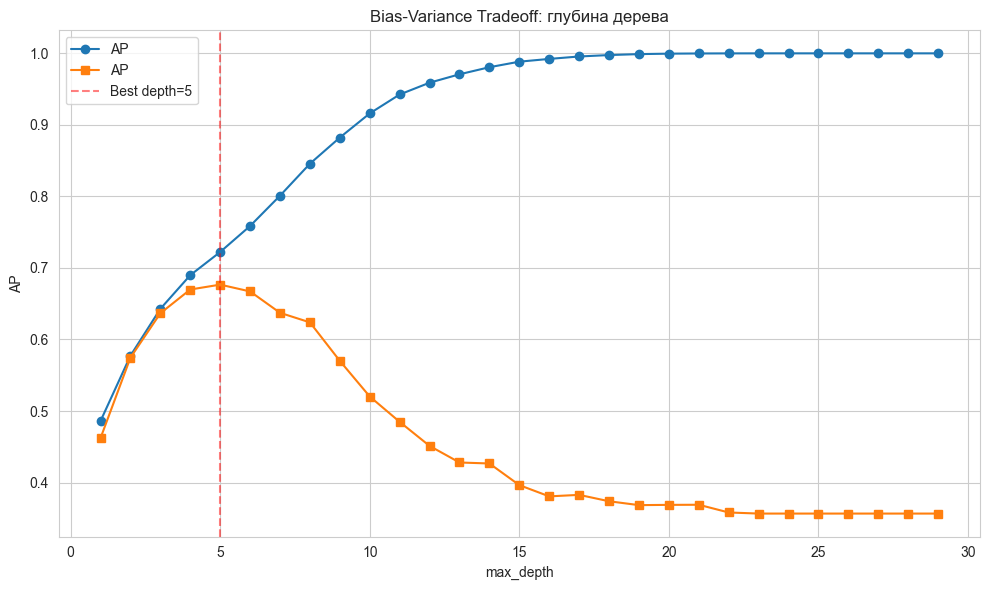

In [41]:
depths = range(1, 30)
train_acc, test_acc = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=2).fit(X_train_sc, y_train)
    train_acc.append(average_precision_score(y_train, dt.predict_proba(X_train_sc)[:,1]))
    test_acc.append(average_precision_score(y_val, dt.predict_proba(X_val_sc)[:,1]))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_acc, 'o-', label='AP')
ax.plot(depths, test_acc, 's-', label='AP')
ax.axvline(x=depths[np.argmax(test_acc)], color='red', linestyle='--', alpha=0.5,
           label=f'Best depth={depths[np.argmax(test_acc)]}')
ax.set_xlabel('max_depth')
ax.set_ylabel('AP')
ax.set_title('Bias-Variance Tradeoff: глубина дерева')
ax.legend()
plt.tight_layout()
plt.show()

## 5.3 Регуляризация деревьев

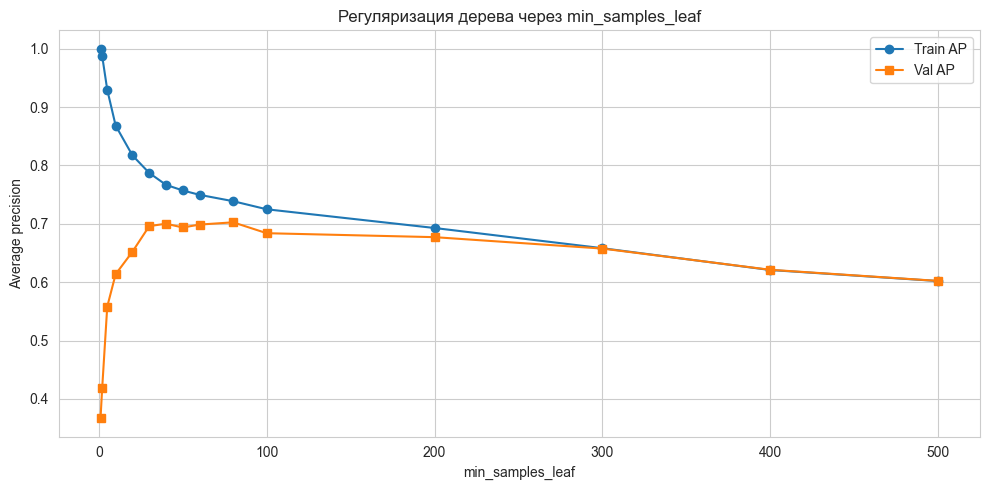

In [42]:
leafs = [1, 2, 5, 10, 20, 30, 40, 50, 60, 80, 100, 200, 300, 400, 500]
train_ap, val_ap = [], []

for ml in leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=ml, random_state=42).fit(X_train_sc, y_train)
    y_train_proba = dt.predict_proba(X_train_sc)[:,1]
    y_val_proba = dt.predict_proba(X_val_sc)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(leafs, train_ap, 'o-', label='Train AP')
ax.plot(leafs, val_ap, 's-', label='Val AP')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Average precision')
ax.set_title('Регуляризация дерева через min_samples_leaf')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Кривые обучения (learning curve)

Показывают, как train/validation качество меняется с ростом объёма обучающих данных —
помогает отличить high bias (обе кривые низко) от high variance (большой разрыв).

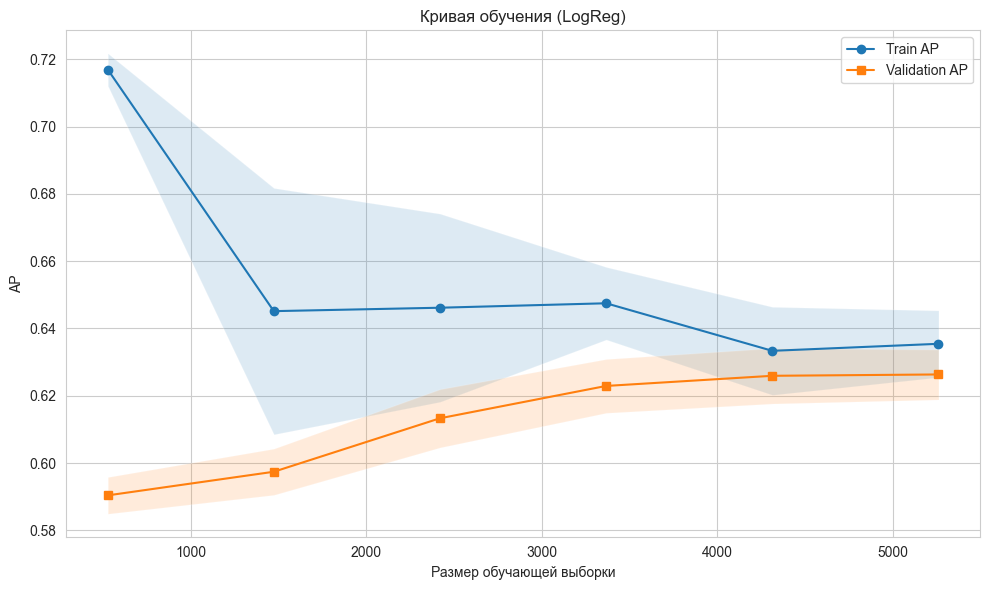

In [43]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, y_train, train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3, scoring='average_precision', n_jobs=-1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sizes, train_sc.mean(1), 'o-', label='Train AP')
ax.fill_between(sizes, train_sc.mean(1) - train_sc.std(1), train_sc.mean(1) + train_sc.std(1), alpha=0.15)
ax.plot(sizes, val_sc.mean(1), 's-', label='Validation AP')
ax.fill_between(sizes, val_sc.mean(1) - val_sc.std(1), val_sc.mean(1) + val_sc.std(1), alpha=0.15)
ax.set_xlabel('Размер обучающей выборки'); ax.set_ylabel('AP')
ax.set_title('Кривая обучения (LogReg)'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Кросс-валидация и подбор гиперпараметров

**K-Fold CV:** разбиваем train на $K$ частей, обучаем на $K-1$, валидируем на 1. Повторяем $K$ раз.

**Stratified K-Fold:** сохраняет пропорции классов.

## 6.1 Decision tree подбор параметров одного дерева

In [44]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'DecisionTree (d=None)': DecisionTreeClassifier(random_state=42),
}

cv_results = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='average_precision')
    cv_results.append({'Model': name, 'CV AP mean': scores.mean(), 'CV AP std': scores.std()})

pd.DataFrame(cv_results).set_index('Model').round(4)

,CV AP mean,CV AP std
Model,,
LogReg,0.6298,0.0331
DecisionTree (d=5),0.6684,0.0177
DecisionTree (d=None),0.3701,0.0113


In [45]:
tree_pipeline = Pipeline ( [
    ("preprocessor", clone(preprocessor)),
    ("model", DecisionTreeClassifier())

])



### 6.1.0 Обучение при дефолтных параметрах

In [46]:
tree_pipeline_noopt = clone(tree_pipeline)
tree_pipeline_noopt.fit(X_train, y_train)

val_pred = tree_pipeline_noopt.predict(X_val)
val_proba = tree_pipeline_noopt.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))
method_name = 'Decision Tree default'
model_results[method_name] = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_estimator": tree_pipeline_noopt
}


AP: 0.3631740728456223
F1: 0.5391014975041597
ROC-AUC: 0.7254059047843693


### 6.1.1 Скан по каждому из параметров

Последовательно перебираем каждый из параметров, чтобы понять в каких диапазонах запускать randomized search. Пока разведка без кросс-валидации.
На валидации лучшие значения max_depth = 5, min_samples_leaf=81, от min_samples_split при малых значениях практически не зависит, падает при значениях выше 175


#### 6.1.1.1 Max depth

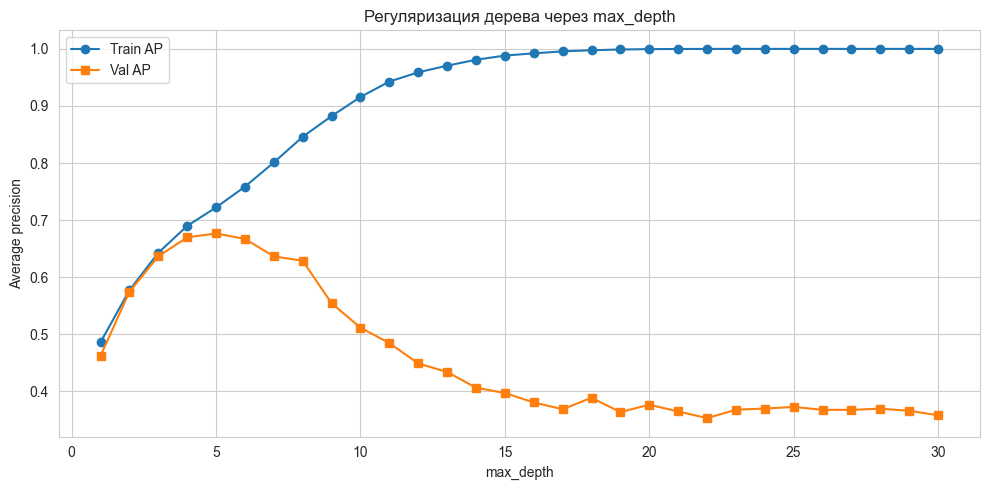

In [47]:
max_depths = np.arange(1,31,1)
train_ap, val_ap = [], []

tree_pipeline_md = clone(tree_pipeline)

for md in max_depths:
    tree_pipeline_md = clone(tree_pipeline)
    tree_pipeline_md.set_params(model__max_depth=md)
    dt = tree_pipeline_md.fit(X_train, y_train)
    y_train_proba = dt.predict_proba(X_train)[:,1]
    y_val_proba = dt.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(max_depths, train_ap, 'o-', label='Train AP')
ax.plot(max_depths, val_ap, 's-', label='Val AP')
ax.set_xlabel('max_depth')
ax.set_ylabel('Average precision')
ax.set_title('Регуляризация дерева через max_depth')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.1.1.2 Min samples leaf

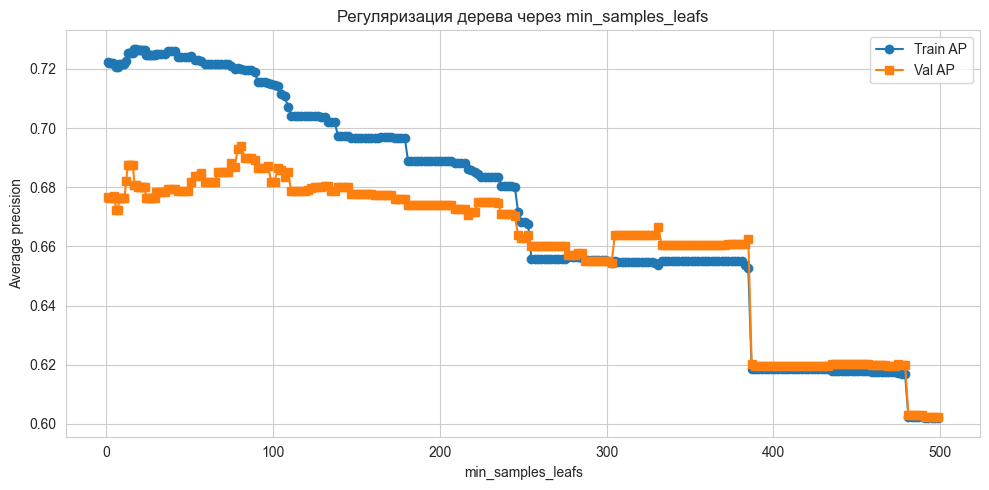

In [48]:
min_samples_leafs = np.concatenate((np.arange(1,31,1), np.arange(31, 500, 2)))
train_ap, val_ap = [], []


for ms in min_samples_leafs:
    tree_pipeline_leafs = clone(tree_pipeline)
    tree_pipeline_leafs.set_params(model__max_depth=5)
    tree_pipeline_leafs.set_params(model__min_samples_leaf = ms)
    dt = tree_pipeline_leafs.fit(X_train, y_train)
    y_train_proba = dt.predict_proba(X_train)[:,1]
    y_val_proba = dt.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(min_samples_leafs, train_ap, 'o-', label='Train AP')
ax.plot(min_samples_leafs, val_ap, 's-', label='Val AP')
ax.set_xlabel('min_samples_leafs')
ax.set_ylabel('Average precision')
ax.set_title('Регуляризация дерева через min_samples_leafs')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.1.1.3 Min samples split

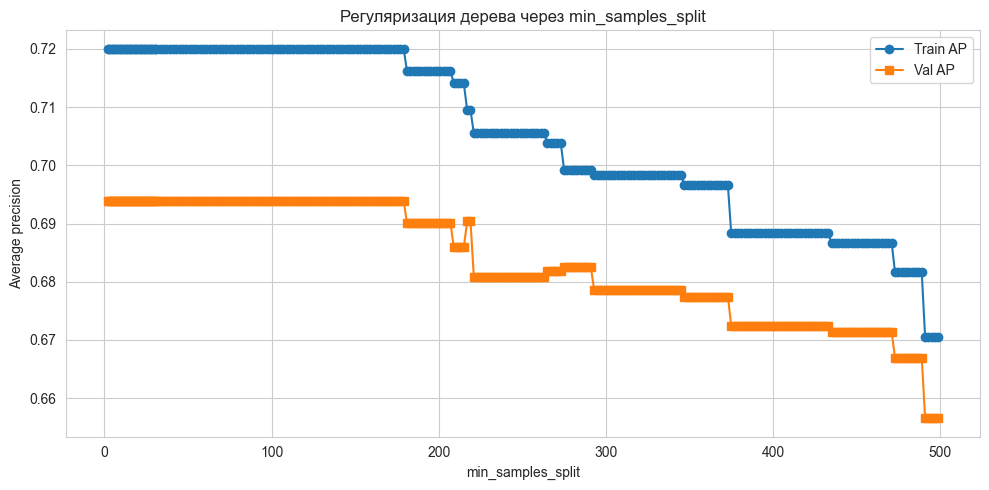

In [49]:
min_samples_split = np.concatenate((np.arange(2,31,1), np.arange(31, 500, 2)))
train_ap, val_ap = [], []


for ms in min_samples_split:
    tree_pipeline_samples_split = clone(tree_pipeline)
    tree_pipeline_samples_split.set_params(model__max_depth=5, model__min_samples_leaf=81)
    tree_pipeline_samples_split.set_params(model__min_samples_split = ms)
    dt = tree_pipeline_samples_split.fit(X_train, y_train)
    y_train_proba = dt.predict_proba(X_train)[:,1]
    y_val_proba = dt.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(min_samples_split, train_ap, 'o-', label='Train AP')
ax.plot(min_samples_split, val_ap, 's-', label='Val AP')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('Average precision')
ax.set_title('Регуляризация дерева через min_samples_split')
ax.legend()
plt.tight_layout()
plt.show()

### 6.1.2 Grid Search

In [50]:
param_grid = {
    'model__max_depth': [3, 5, 7, 10, 15, 20, 30, 40, None],
    'model__min_samples_split': [2, 5, 10, 20, 30, 50, 100, 200, 300, 500],
    'model__min_samples_leaf': [1, 2, 3,4,5, 7, 10, 15, 20, 30, 50],
    'model__criterion': ['gini', 'entropy'],
}


tree_search = GridSearchCV(
    estimator = tree_pipeline,
    param_grid = param_grid,
    scoring={
    "average_precision": "average_precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
)
tree_search.fit(X_train, y_train)

tree_search.best_params_, tree_search.best_score_.round(4)

({'model__criterion': 'gini',
  'model__max_depth': 7,
  'model__min_samples_leaf': 30,
  'model__min_samples_split': 5},
 np.float64(0.6901))

In [51]:
best_tree = tree_search.best_estimator_

val_pred = best_tree.predict(X_val)
val_proba = best_tree.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))

AP: 0.698336313806027
F1: 0.6276595744680851
ROC-AUC: 0.915384086173684


### 6.1.2 Randomized search

In [52]:
from scipy.stats import randint, uniform

param_dist = {
    'model__max_depth': randint(1, 20),
    'model__min_samples_split': randint(2, 200),
    'model__min_samples_leaf': randint(1, 200),
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': [None, 'Balanced']
}

tree_search_rand = RandomizedSearchCV(
    estimator = tree_pipeline,
    param_distributions = param_dist,
    scoring={
    "average_precision": "average_precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
    n_iter=5000
)
tree_search_rand.fit(X_train, y_train)

tree_search_rand.best_params_, tree_search_rand.best_score_.round(4)

({'model__class_weight': None,
  'model__criterion': 'entropy',
  'model__max_depth': 7,
  'model__min_samples_leaf': 34,
  'model__min_samples_split': 22},
 np.float64(0.6929))

In [53]:
best_tree_rand = tree_search_rand.best_estimator_

val_pred = best_tree_rand.predict(X_val)
val_proba = best_tree_rand.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))

AP: 0.688977574867606
F1: 0.6222222222222222
ROC-AUC: 0.9152297833864056


In [54]:
method_name = 'Decision Tree Rand Search'
model_results[method_name] = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_params": tree_search_rand.best_params_,
    "Best_estimator": tree_search_rand.best_estimator_
}


In [55]:
model_results[method_name]

{'Accuracy': 0.8966041561074506,
 'Precision': 0.7148936170212766,
 'Recall': 0.5508196721311476,
 'F1': 0.7811639590265544,
 'ROC_AUC': np.float64(0.9152297833864056),
 'AP': np.float64(0.688977574867606),
 'LogLoss': 0.29160349511372746,
 'Best_params': {'model__class_weight': None,
  'model__criterion': 'entropy',
  'model__max_depth': 7,
  'model__min_samples_leaf': 34,
  'model__min_samples_split': 22},
 'Best_estimator': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['Administrative',
                                                    'Administrative_Duration',
                                                    'Informational',
                                                    'Informational_Duration',
                                                    'ProductRelated',
                                                    'ProductRelated_Duration',
               

In [56]:
best_tree_rand["model"].feature_importances_

array([0.00818044, 0.02445335, 0.        , 0.        , 0.02684678,
       0.01980939, 0.05037781, 0.01612163, 0.7240341 , 0.        ,
       0.        , 0.        , 0.        , 0.0075922 , 0.        ,
       0.        , 0.00155468, 0.00111953, 0.        , 0.11991009])

In [57]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

### 6.1.3 Отбор признаков

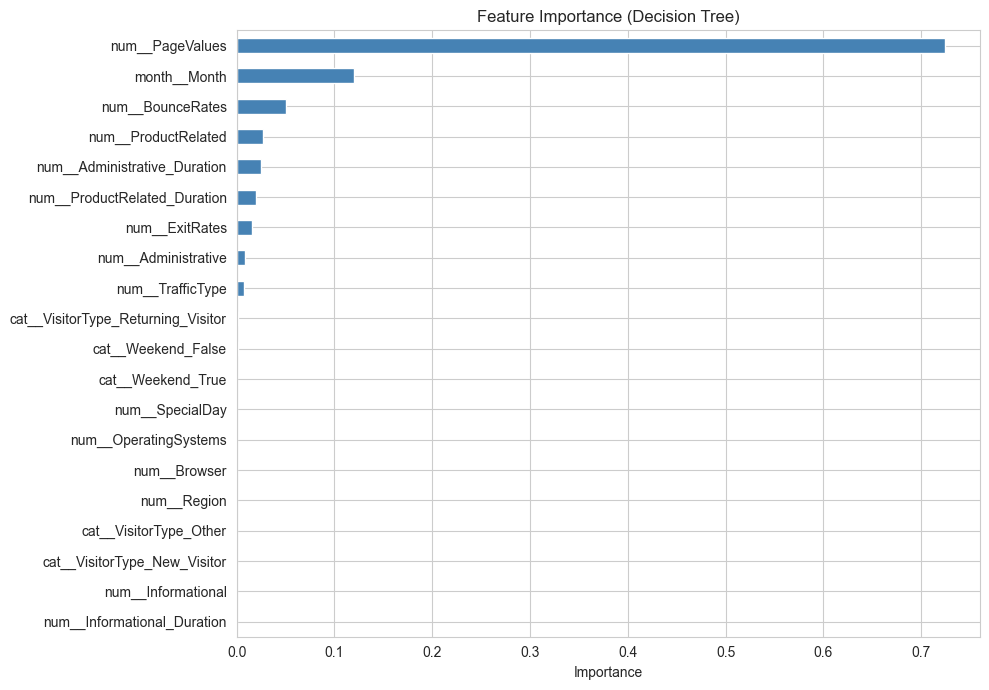

In [58]:
feature_names = (
    best_tree_rand.named_steps["preprocessor"]
    .get_feature_names_out()
)
importances = pd.Series(best_tree_rand["model"].feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Decision Tree)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6.2 Random forest подбор параметров

In [59]:
random_forest_pipeline_default = Pipeline ( [
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(

    ))
])

random_forest_pipeline = Pipeline ( [
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        max_features=11,
        min_samples_leaf=11,
        min_samples_split=28,
        n_jobs=-1

    ))
])

### 6.2.0 Обучение при дефолтных параметрах

In [60]:
rf_pipeline_noopt = clone(random_forest_pipeline_default)
rf_pipeline_noopt.fit(X_train, y_train)

val_pred = rf_pipeline_noopt.predict(X_val)
val_proba = rf_pipeline_noopt.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))
method_name = 'Random forest default'
model_results[method_name] = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_estimator": rf_pipeline_noopt
}


AP: 0.7374152293352404
F1: 0.6344294003868471
ROC-AUC: 0.9189733459134332


Последовательно сканируем каждый параметр, чтобы понять какие диапазоны передавать в RandomizedSearch.
При числе деревьев >300 AP практически не растёт, оставляем 300. Max depth 6, max_features = 11, min_samples leaf ==11, min_samples split = 28 - по одномерным сканам. 

### 6.2.1 Скан по каждому из гиперпараметров

#### 6.2.1.1 n_estimators

In [61]:
n_estimators_arr = np.concatenate((np.arange(1,31,2), np.arange(31, 100,5), np.arange(100, 1001, 50)))
train_ap, val_ap = [], []



for n_est in n_estimators_arr:
    forest_pipeline_nest = clone(random_forest_pipeline)
    forest_pipeline_nest.set_params(model__n_estimators=n_est)
    rf = forest_pipeline_nest.fit(X_train, y_train)
    y_train_proba = rf.predict_proba(X_train)[:,1]
    y_val_proba = rf.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))


In [62]:
best_n_est = n_estimators_arr[np.argmax(val_ap)]
print (f"Best n estimators: {best_n_est:.0f}")

Best n estimators: 86


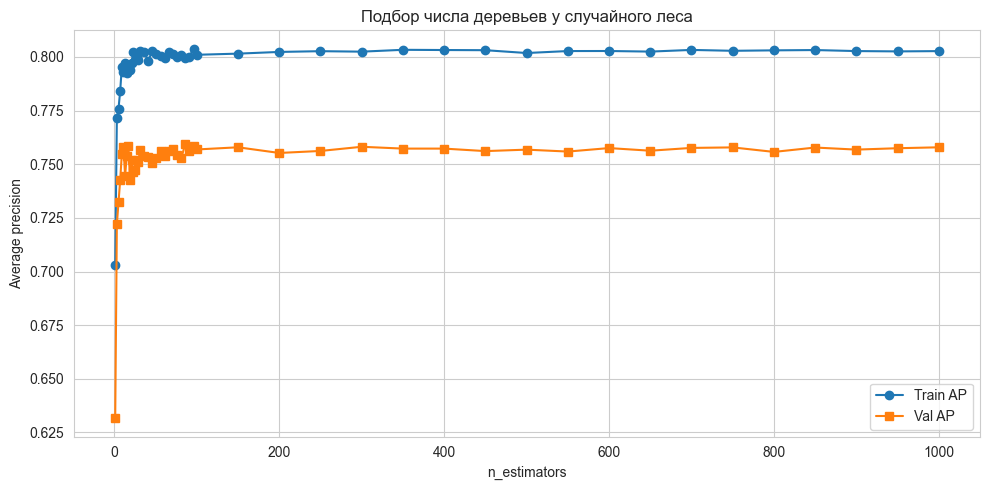

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_estimators_arr, train_ap, 'o-', label='Train AP')
ax.plot(n_estimators_arr, val_ap, 's-', label='Val AP')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Average precision')
ax.set_title('Подбор числа деревьев у случайного леса')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.2.1.2 max_depth

In [64]:
max_depths_arr = np.arange(1,51,1)
train_ap, val_ap = [], []



for max_depth in max_depths_arr:
    forest_pipeline_curr = clone(random_forest_pipeline)
    forest_pipeline_curr.set_params(model__n_estimators=300)
    forest_pipeline_curr.set_params(model__max_depth=max_depth)
    rf = forest_pipeline_curr.fit(X_train, y_train)
    y_train_proba = rf.predict_proba(X_train)[:,1]
    y_val_proba = rf.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))


In [65]:
best_max_depth = max_depths_arr[np.argmax(val_ap)]
print (f"Best max depth: {best_max_depth:.0f}")

Best max depth: 24


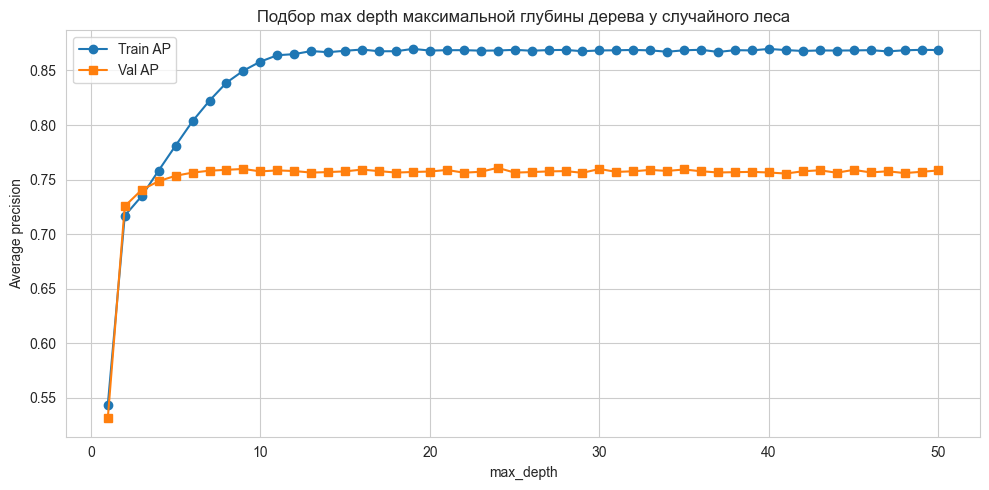

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(max_depths_arr, train_ap, 'o-', label='Train AP')
ax.plot(max_depths_arr, val_ap, 's-', label='Val AP')
ax.set_xlabel('max_depth')
ax.set_ylabel('Average precision')
ax.set_title('Подбор max depth максимальной глубины дерева у случайного леса')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.2.1.3 max_features

In [67]:
max_features_arr = np.arange(1,40,1)
train_ap, val_ap = [], []



for max_feat in max_features_arr:
    forest_pipeline_curr = clone(random_forest_pipeline)
    forest_pipeline_curr.set_params(model__n_estimators=300)
    forest_pipeline_curr.set_params(model__max_depth=6)
    forest_pipeline_curr.set_params(model__max_features=max_feat)
    rf = forest_pipeline_curr.fit(X_train, y_train)
    y_train_proba = rf.predict_proba(X_train)[:,1]
    y_val_proba = rf.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))


In [68]:
best_max_feat = max_features_arr[np.argmax(val_ap)]
print (f"Best max features: {best_max_feat:.0f}")

Best max features: 10


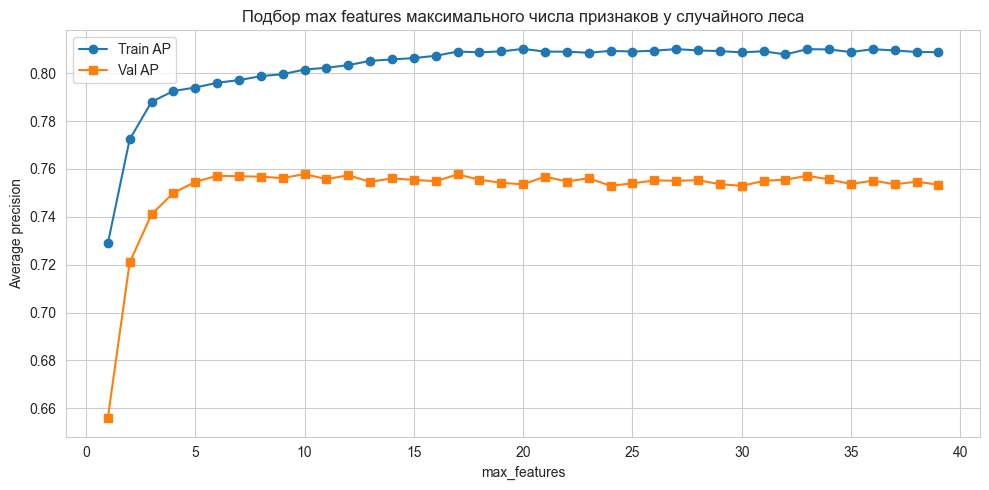

In [69]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(max_features_arr, train_ap, 'o-', label='Train AP')
ax.plot(max_features_arr, val_ap, 's-', label='Val AP')
ax.set_xlabel('max_features')
ax.set_ylabel('Average precision')
ax.set_title('Подбор max features максимального числа признаков у случайного леса')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.2.1.4 min_samples_leaf

In [70]:
min_samples_leafs_arr = np.arange(1,50,2)
train_ap, val_ap = [], []



for min_samples_leaf in min_samples_leafs_arr:
    forest_pipeline_curr = clone(random_forest_pipeline)
    forest_pipeline_curr.set_params(model__n_estimators=300)
    forest_pipeline_curr.set_params(model__max_depth=6)
    forest_pipeline_curr.set_params(model__max_features=11)
    forest_pipeline_curr.set_params(model__min_samples_leaf=min_samples_leaf)
    rf = forest_pipeline_curr.fit(X_train, y_train)
    y_train_proba = rf.predict_proba(X_train)[:,1]
    y_val_proba = rf.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))


In [71]:
best_min_samples_leaf = min_samples_leafs_arr[np.argmax(val_ap)]
print (f"Best min_samples_leaf: {best_min_samples_leaf:.0f}")

Best min_samples_leaf: 15


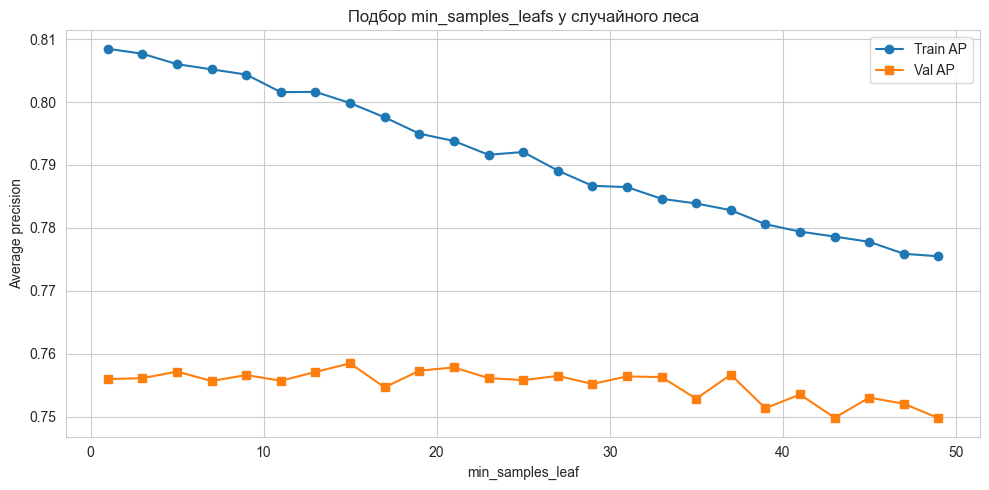

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(min_samples_leafs_arr, train_ap, 'o-', label='Train AP')
ax.plot(min_samples_leafs_arr, val_ap, 's-', label='Val AP')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Average precision')
ax.set_title('Подбор min_samples_leafs у случайного леса')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.2.1.5 min_samples_split

In [73]:
min_samples_split_arr = np.concatenate((np.arange(2,100,2), np.arange(100,501,5)))
train_ap, val_ap = [], []



for min_samples_split in min_samples_split_arr:
    forest_pipeline_curr = clone(random_forest_pipeline)
    forest_pipeline_curr.set_params(model__n_estimators=300)
    forest_pipeline_curr.set_params(model__max_depth=6)
    forest_pipeline_curr.set_params(model__max_features=11)
    forest_pipeline_curr.set_params(model__min_samples_leaf=11)
    forest_pipeline_curr.set_params(model__min_samples_split=min_samples_split)
    rf = forest_pipeline_curr.fit(X_train, y_train)
    y_train_proba = rf.predict_proba(X_train)[:,1]
    y_val_proba = rf.predict_proba(X_val)[:,1]
    train_ap.append(average_precision_score(y_train, y_train_proba))
    val_ap.append(average_precision_score(y_val, y_val_proba))


In [74]:
best_min_samples_split = min_samples_split_arr[np.argmax(val_ap)]
print (f"Best min_samples_leaf: {best_min_samples_split:.0f}")

Best min_samples_leaf: 10


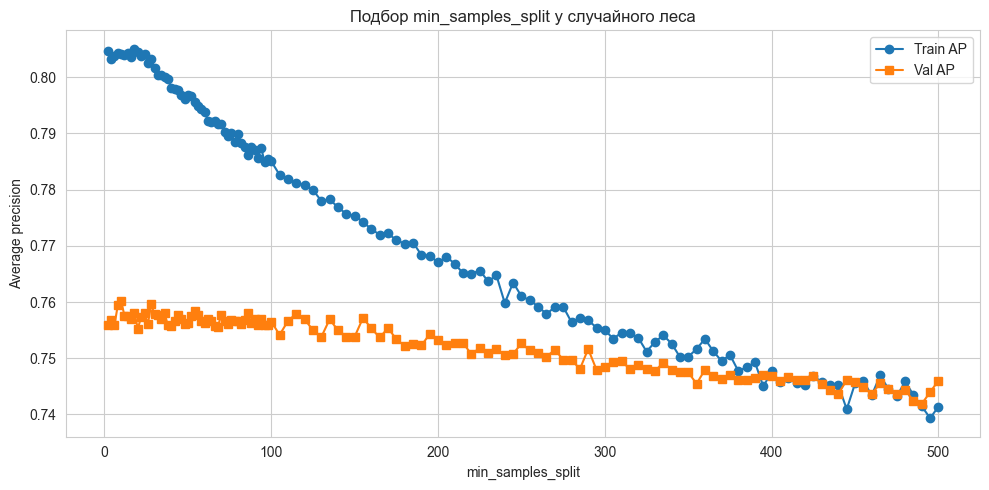

In [75]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(min_samples_split_arr, train_ap, 'o-', label='Train AP')
ax.plot(min_samples_split_arr, val_ap, 's-', label='Val AP')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('Average precision')
ax.set_title('Подбор min_samples_split у случайного леса')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2.2 Randomized Search

Последовательно сканируем каждый параметр, чтобы понять какие диапазоны передавать в RandomizedSearch.
При числе деревьев >300 AP практически не растёт, оставляем 300. Max depth 6, max_features = 11, min_samples leaf ==11, min_samples split = 28 - по одномерным сканам. 

In [76]:
from scipy.stats import randint, uniform

param_dist = {
    'model__n_estimators': randint(1, 1000),
    'model__min_samples_split': randint(1, 300),
    'model__min_samples_leaf': randint(1, 50),
    'model__max_depth': randint(1,20),
    'model__max_features': randint(1,18),
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': [None, 'Balanced']
}

rf_search_rand = RandomizedSearchCV(
    estimator = random_forest_pipeline,
    param_distributions = param_dist,
    scoring={
    "average_precision": "average_precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
    n_iter=500,
    verbose=1,
)
rf_search_rand.fit(X_train, y_train)

rf_search_rand.best_params_, rf_search_rand.best_score_.round(4)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


({'model__class_weight': None,
  'model__criterion': 'entropy',
  'model__max_depth': 13,
  'model__max_features': 12,
  'model__min_samples_leaf': 18,
  'model__min_samples_split': 59,
  'model__n_estimators': 599},
 np.float64(0.7448))

In [77]:
best_rf_rand = rf_search_rand.best_estimator_

val_pred = best_rf_rand.predict(X_val)
val_proba = best_rf_rand.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))

AP: 0.7606448462983608
F1: 0.653211009174312
ROC-AUC: 0.9302865903998112


In [78]:
method_name = 'Random Forest Rand Search'
model_results[method_name] = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_params": rf_search_rand.best_params_,
    "Best_estimator": rf_search_rand.best_estimator_
}


In [79]:
model_results

{'LogReg: CV + OOF threshold': {'Threshold': 0.5344823408836192,
  'Accuracy': 0.8748099341104917,
  'Precision': 0.5843023255813954,
  'Recall': 0.659016393442623,
  'F1': 0.7722489464905529,
  'ROC_AUC': np.float64(0.8901265872547863),
  'AP': np.float64(0.6239636645277276),
  'LogLoss': 0.43858808262182697,
  'Best_params': {'model__C': np.float64(0.01), 'model__penalty': 'l1'},
  'Best_estimator': Pipeline(steps=[('preprocessor',
                   ColumnTransformer(transformers=[('num', StandardScaler(),
                                                    ['Administrative',
                                                     'Administrative_Duration',
                                                     'Informational',
                                                     'Informational_Duration',
                                                     'ProductRelated',
                                                     'ProductRelated_Duration',
                                  

## 6.3 Gradient boosting подбор параметров

In [80]:
grad_boosting_pipeline_default = Pipeline ([
    ("preprocessor", clone(preprocessor)),
    ("model", HistGradientBoostingClassifier(

    ))
])

grad_boosting_pipeline = Pipeline ([
    ("preprocessor", clone(preprocessor)),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.03,
        random_state= 100,
        max_iter=300,
        max_depth = 5,
        l2_regularization = 0.0,
        max_features = 1.0,
        min_samples_leaf = 110,
        max_leaf_nodes = 10,
        
    ))
])

### 6.3.0 Обучение при дефолтных параметрах

In [81]:
gb_pipeline_noopt = clone(grad_boosting_pipeline_default)
gb_pipeline_noopt.fit(X_train, y_train)

val_pred = gb_pipeline_noopt.predict(X_val)
val_proba = gb_pipeline_noopt.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))
method_name = 'Gradient Boosting default'
model_results[method_name] = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_estimator": gb_pipeline_noopt
}


AP: 0.746206967978913
F1: 0.644927536231884
ROC-AUC: 0.9261528482132326


### 6.3.1 Скан по гиперпараметрам

In [82]:
params_arrays = [('model__learning_rate', np.logspace(-4, 0,31)), ['model__max_depth', np.arange(1,20,1)],  ['model__l2_regularization', np.logspace(-5,1,11)], ['model__max_leaf_nodes', np.arange(2,50,2)], ['model__min_samples_leaf', np.arange(10,201,10)], ['model__max_features', np.linspace(0.01, 1.0, 21)]]

In [83]:
train_ap_all = {}
val_ap_all = {}
for par_name, par_values in params_arrays:
    train_ap_1d, val_ap_1d = [], []
    for par_value in par_values:
        grad_boosting_pipeline_curr = clone(grad_boosting_pipeline)
        grad_boosting_pipeline_curr.set_params(**{par_name:par_value})
        gb = grad_boosting_pipeline_curr.fit(X_train, y_train)

        y_train_proba = gb.predict_proba(X_train)[:,1]
        y_val_proba = gb.predict_proba(X_val)[:,1]
        train_ap_1d.append(average_precision_score(y_train, y_train_proba))
        val_ap_1d.append(average_precision_score(y_val, y_val_proba))
    train_ap_all[par_name]=train_ap_1d
    val_ap_all[par_name]=val_ap_1d


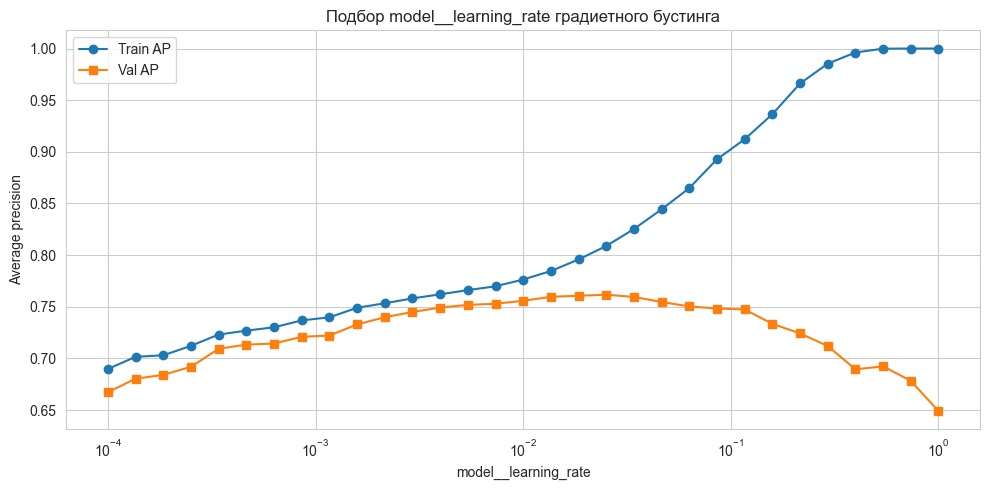

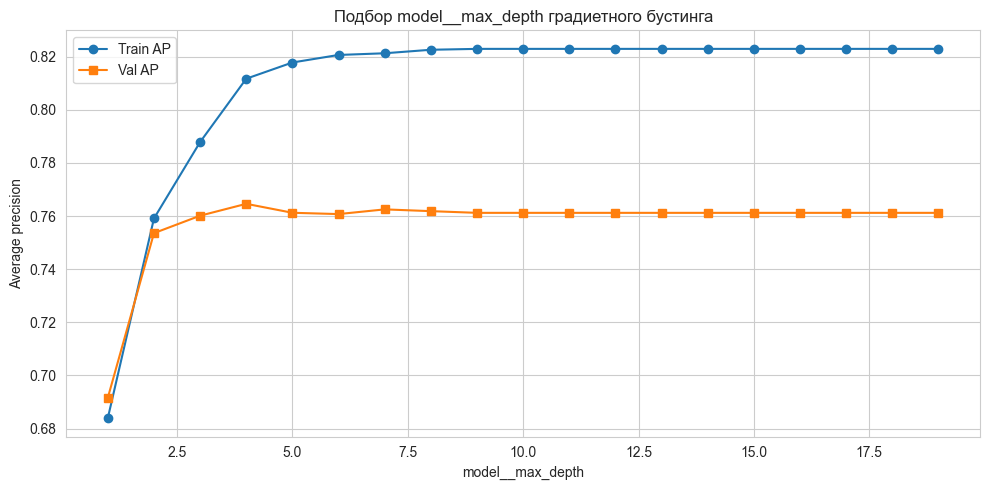

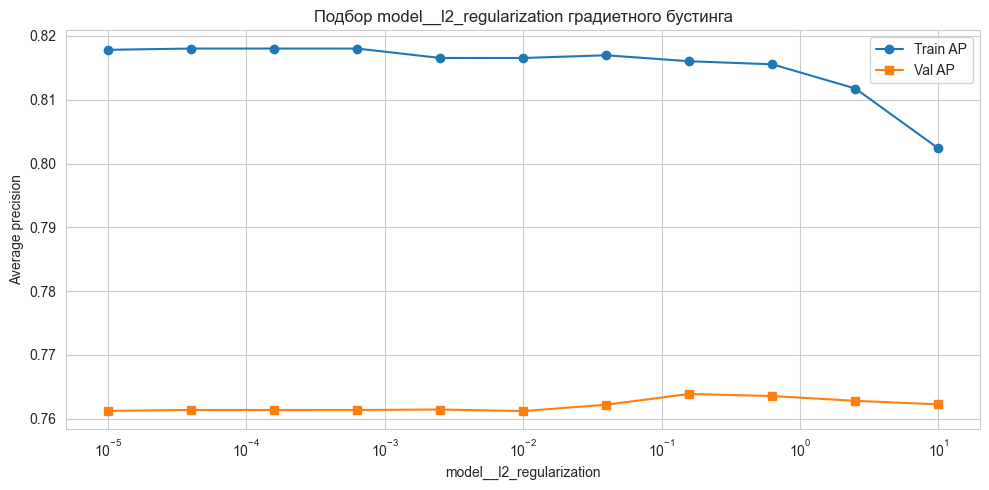

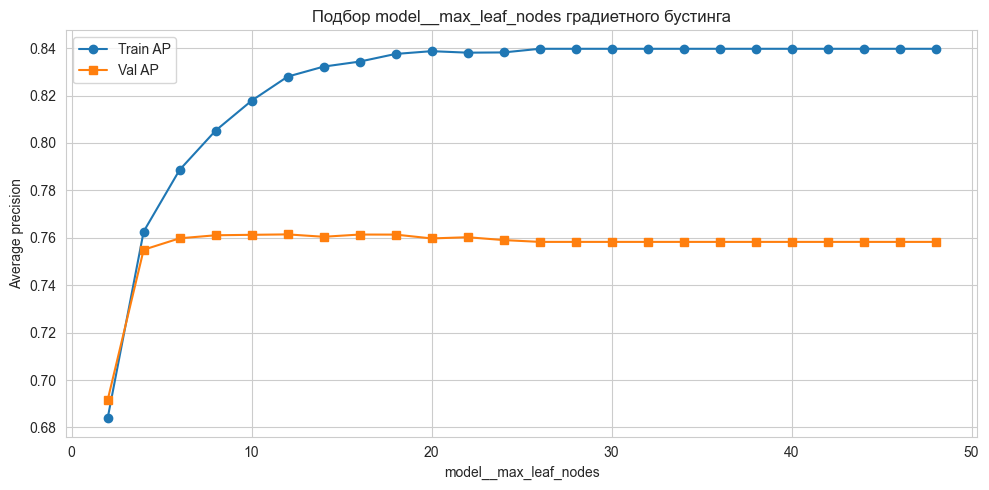

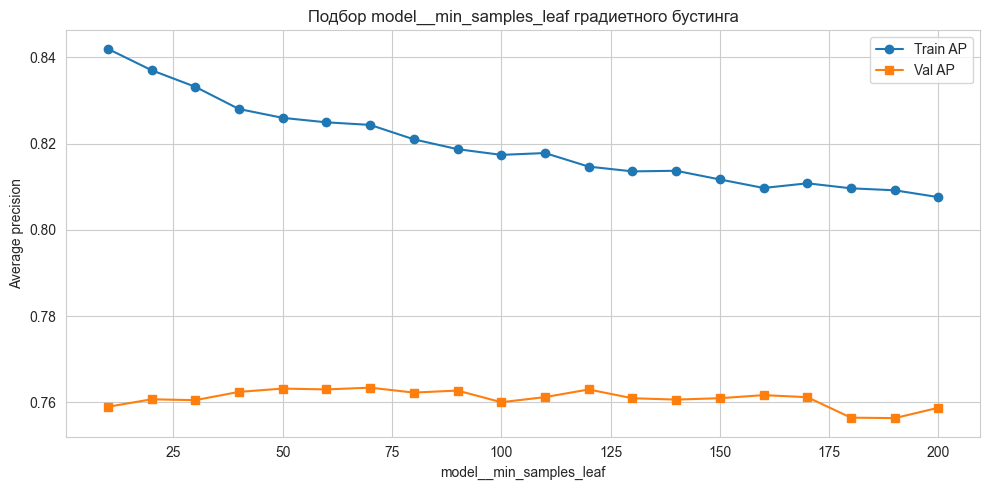

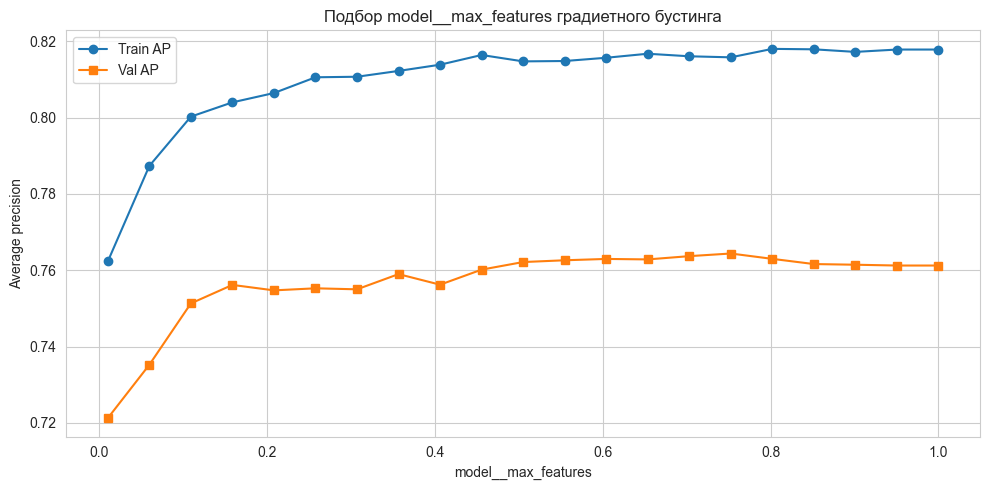

In [84]:
for par_name, par_values in params_arrays:
    train_ap_1d = train_ap_all[par_name]
    val_ap_1d = val_ap_all[par_name]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(par_values, train_ap_1d, 'o-', label='Train AP')
    ax.plot(par_values, val_ap_1d, 's-', label='Val AP')

    if (abs(2*par_values[1]-par_values[0] -par_values[2]) >1e-7):
        ax.set_xscale('log')
    ax.set_xlabel(par_name)
    ax.set_ylabel('Average precision')
    ax.set_title(f'Подбор {par_name} градиетного бустинга')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 6.3.2 RandomizedSearch Gradient Boosting

In [93]:
from scipy.stats import randint, uniform, loguniform

param_dist_gb = {
    'model__learning_rate': loguniform(1e-4,1),
    'model__max_depth': randint(1, 20),
    'model__l2_regularization': loguniform(1e-5, 1),
    'model__max_leaf_nodes': randint(1,60),
    'model__min_samples_leaf': randint(1,200),
    'model__max_features': uniform(0,1),

    'model__class_weight': [None, 'Balanced']
}

gb_search_rand = RandomizedSearchCV(
    estimator = grad_boosting_pipeline,
    param_distributions = param_dist_gb,
    scoring={
    "average_precision": "average_precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
    n_iter=5000,
    verbose=1,
)
gb_search_rand.fit(X_train, y_train)

gb_search_rand.best_params_, gb_search_rand.best_score_.round(4)

({'model__class_weight': None,
  'model__l2_regularization': np.float64(0.0534128758649907),
  'model__learning_rate': np.float64(0.010234304475893283),
  'model__max_depth': 8,
  'model__max_features': np.float64(0.569121503168441),
  'model__max_leaf_nodes': 50,
  'model__min_samples_leaf': 53},
 np.float64(0.75))

In [94]:
best_gb_rand = gb_search_rand.best_estimator_

val_pred = best_gb_rand.predict(X_val)
val_proba = best_gb_rand.predict_proba(X_val)[:, 1]

print("AP:", average_precision_score(y_val, val_proba))
print("F1:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))

AP: 0.7631050127240039
F1: 0.6543438077634011
ROC-AUC: 0.932348547391595


In [95]:
method_name = 'Gradien Boosting Rand Search'
model_results[method_name] = {
    "Accuracy": accuracy_score(y_val, val_pred),
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0, average='macro'),
    "ROC_AUC": roc_auc_score(y_val, val_proba),
    "AP": average_precision_score(y_val, val_proba),
    "LogLoss": log_loss(y_val, val_proba),
    "Best_params": tree_search_rand.best_params_,
    "Best_estimator": gb_search_rand.best_estimator_
}

In [96]:
model_results.keys()

dict_keys(['LogReg: CV + OOF threshold', 'Decision Tree default', 'Decision Tree Rand Search', 'Random forest default', 'Random Forest Rand Search', 'Gradient Boosting default', 'Gradien Boosting Rand Search'])

# 7. Отбор признаков

## 7.1 Decision tree feature importance 

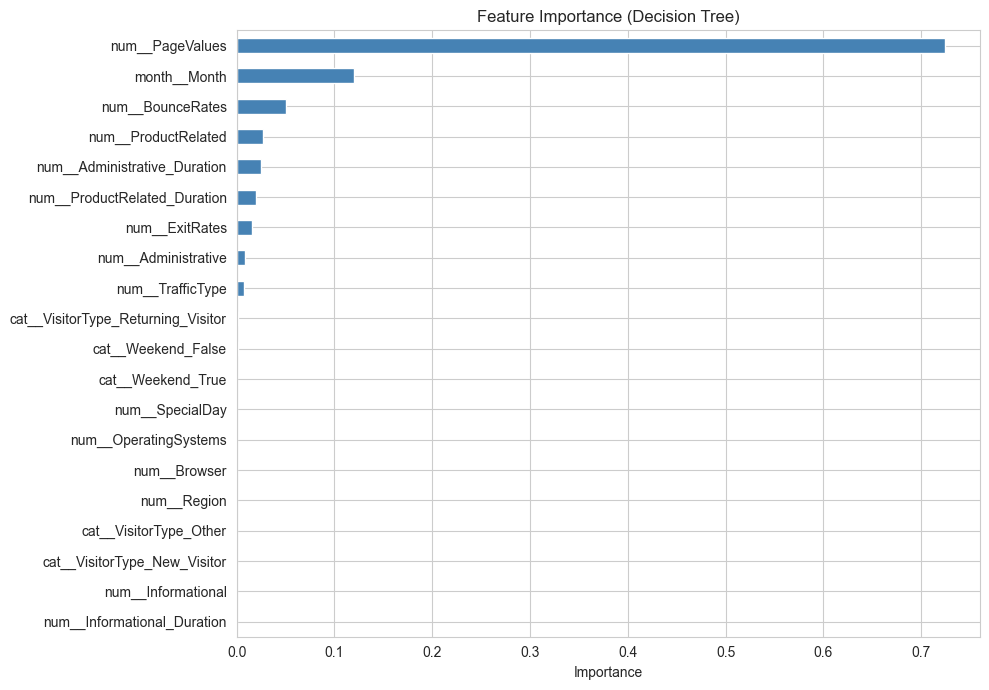

In [113]:
best_dt = model_results['Decision Tree Rand Search']['Best_estimator']
importances = pd.Series(best_dt['model'].feature_importances_, index=best_dt["preprocessor"].get_feature_names_out()).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Decision Tree)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7.2 RFECV

In [115]:
best_dt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['VisitorType', 'Weekend']),
                                                 ('month', 'passthrough',
                                                  ['Month'])])),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=7,
                                        min_samples_leaf=34,
                                        min_samples_split=22))])

### 7.2.1 Decision tree

In [116]:
from sklearn.base import clone
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

rfe_pipeline = Pipeline([
    ("preprocessor", clone(best_dt["preprocessor"])),
    ("selector", RFE(estimator=clone(best_dt["model"]), step=1)),
    ("model", clone(best_dt["model"])),
])

n_features = len(best_dt["preprocessor"].get_feature_names_out())

rfe_search = GridSearchCV(
    rfe_pipeline,
    param_grid={
        "selector__n_features_to_select": range(1, n_features + 1)
    },
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
)
rfe_search.fit(X_train, y_train)

best_pipeline = rfe_search.best_estimator_
selected_features = best_pipeline["preprocessor"].get_feature_names_out()[
    best_pipeline["selector"].support_
]

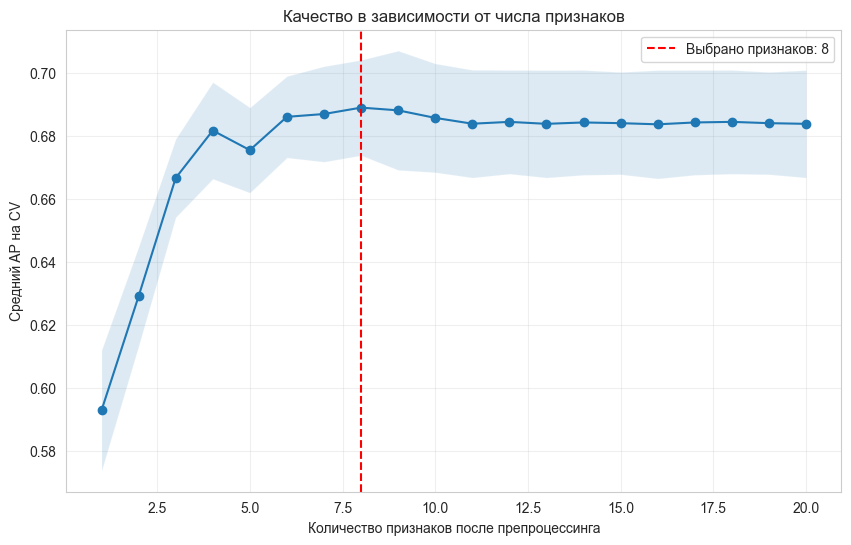

In [118]:
plot_data = pd.DataFrame({
    "n_features": rfe_search.cv_results_[
        "param_selector__n_features_to_select"
    ].astype(int),
    "mean_ap": rfe_search.cv_results_["mean_test_score"],
    "std_ap": rfe_search.cv_results_["std_test_score"],
}).sort_values("n_features")

best_n = rfe_search.best_params_["selector__n_features_to_select"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plot_data["n_features"], plot_data["mean_ap"], "o-")
ax.fill_between(
    plot_data["n_features"],
    plot_data["mean_ap"] - plot_data["std_ap"],
    plot_data["mean_ap"] + plot_data["std_ap"],
    alpha=0.15,
)
ax.axvline(best_n, color="red", linestyle="--",
           label=f"Выбрано признаков: {best_n}")
ax.set_xlabel("Количество признаков после препроцессинга")
ax.set_ylabel("Средний AP на CV")
ax.set_title("Качество в зависимости от числа признаков")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### 7.2.2 Random forest

In [120]:
from sklearn.base import clone
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
best_rf = model_results['Random Forest Rand Search']['Best_estimator']

rfe_pipeline = Pipeline([
    ("preprocessor", clone(best_rf["preprocessor"])),
    ("selector", RFE(estimator=clone(best_rf["model"]), step=1)),
    ("model", clone(best_rf["model"])),
])

n_features = len(best_dt["preprocessor"].get_feature_names_out())

rfe_search = GridSearchCV(
    rfe_pipeline,
    param_grid={
        "selector__n_features_to_select": range(1, n_features + 1)
    },
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
)
rfe_search.fit(X_train, y_train)

best_pipeline = rfe_search.best_estimator_
selected_features = best_pipeline["preprocessor"].get_feature_names_out()[
    best_pipeline["selector"].support_
]

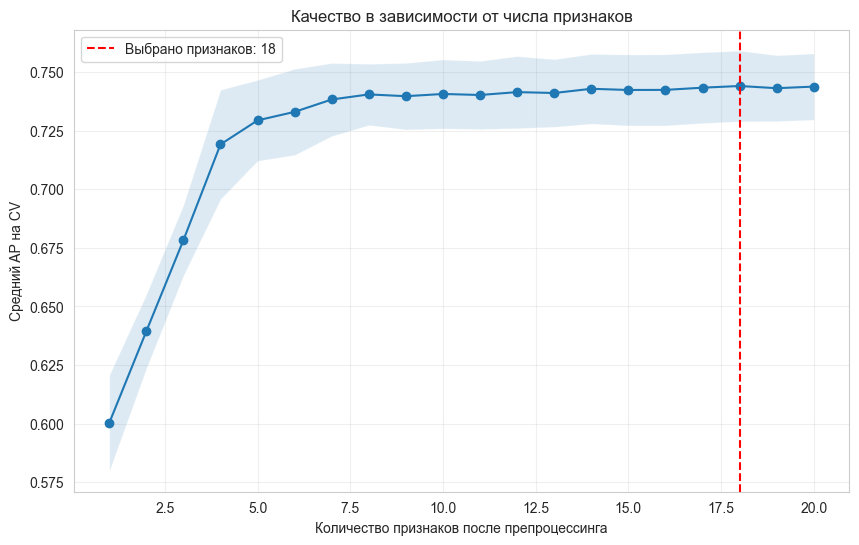

In [121]:
plot_data = pd.DataFrame({
    "n_features": rfe_search.cv_results_[
        "param_selector__n_features_to_select"
    ].astype(int),
    "mean_ap": rfe_search.cv_results_["mean_test_score"],
    "std_ap": rfe_search.cv_results_["std_test_score"],
}).sort_values("n_features")

best_n = rfe_search.best_params_["selector__n_features_to_select"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plot_data["n_features"], plot_data["mean_ap"], "o-")
ax.fill_between(
    plot_data["n_features"],
    plot_data["mean_ap"] - plot_data["std_ap"],
    plot_data["mean_ap"] + plot_data["std_ap"],
    alpha=0.15,
)
ax.axvline(best_n, color="red", linestyle="--",
           label=f"Выбрано признаков: {best_n}")
ax.set_xlabel("Количество признаков после препроцессинга")
ax.set_ylabel("Средний AP на CV")
ax.set_title("Качество в зависимости от числа признаков")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### 7.2.3 Gradient Boosting

In [126]:
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

best_gb = gb_search_rand.best_estimator_
n_features = len(best_gb["preprocessor"].get_feature_names_out())

rows = []
for k in range(1, n_features + 1):
    pipe = Pipeline([
        ("preprocessor", clone(best_gb["preprocessor"])),
        ("selector", SelectKBest(score_func=f_classif, k=k)),
        ("model", clone(best_gb["model"])),
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=10, scoring="average_precision", n_jobs=-1,
    )
    rows.append({
        "n_features": k,
        "mean_ap": scores.mean(),
        "std_ap": scores.std(),
    })

gb_feature_scores = pd.DataFrame(rows)

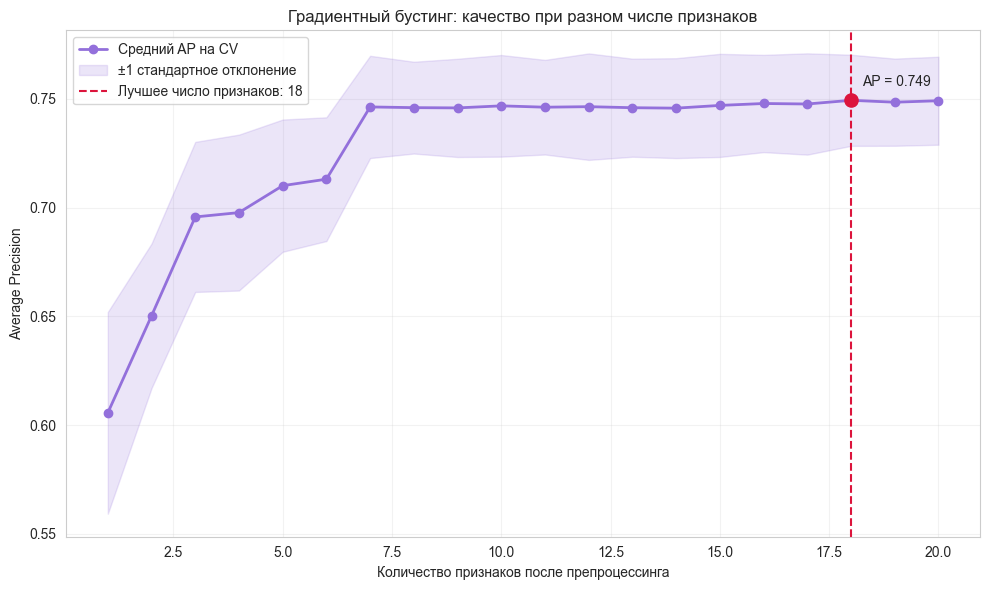

In [127]:
plot_data = gb_feature_scores.sort_values("n_features")
x = plot_data["n_features"].to_numpy()
mean = plot_data["mean_ap"].to_numpy()
std = plot_data["std_ap"].to_numpy()

best_idx = mean.argmax()
best_k = x[best_idx]
best_ap = mean[best_idx]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, mean, "o-", color="mediumpurple", linewidth=2,
        label="Средний AP на CV")
ax.fill_between(x, mean - std, mean + std,
                color="mediumpurple", alpha=0.18,
                label="±1 стандартное отклонение")

ax.axvline(best_k, color="crimson", linestyle="--",
           label=f"Лучшее число признаков: {best_k}")
ax.scatter(best_k, best_ap, color="crimson", s=90, zorder=3)
ax.annotate(f"AP = {best_ap:.3f}",
            (best_k, best_ap), xytext=(8, 10),
            textcoords="offset points")

ax.set(
    xlabel="Количество признаков после препроцессинга",
    ylabel="Average Precision",
    title="Градиентный бустинг: качество при разном числе признаков",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Запуск всех моделей на тесте и построение финальных графиков

In [128]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
)
X_train_val_final = X_train_val.copy()
X_train_val_final["Month"] = X_train_val_final["Month"].map(month_map)

test_rows = {}

for name, info in model_results.items():
    model = clone(info["Best_estimator"])
    model.fit(X_train_val_final, y_train_val)

    threshold = info.get("Threshold", 0.5)

    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    test_rows[name] = {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1_pos": f1_score(y_test, pred, zero_division=0),
        "F1_macro": f1_score(
            y_test, pred, average="macro", zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_test, proba),
        "AP": average_precision_score(y_test, proba),
        "LogLoss": log_loss(y_test, proba),
    }

test_results = (
    pd.DataFrame.from_dict(test_rows, orient="index")
    .rename_axis("Model")
    .sort_values("AP", ascending=False)
)

display(test_results.round(4))
test_results.to_csv("model_test_results.csv", encoding="utf-8-sig")

,Threshold,Accuracy,Precision,Recall,F1_pos,F1_macro,ROC_AUC,AP,LogLoss
Model,,,,,,,,,
Gradien Boosting Rand Search,0.5000,0.9161,0.7743,0.6466,0.7047,0.8279,0.9356,0.7773,0.2194
Random Forest Rand Search,0.5000,0.9112,0.7447,0.6492,0.6937,0.8209,0.9342,0.7753,0.2187
Gradient Boosting default,0.5000,0.9092,0.7337,0.6492,0.6889,0.8179,0.9325,0.7643,0.2238
Random forest default,0.5000,0.9088,0.7591,0.6021,0.6715,0.8093,0.9207,0.7430,0.2970
Decision Tree Rand Search,0.5000,0.9023,0.7224,0.5995,0.6552,0.7991,0.9282,0.7382,0.2748
LogReg: CV + OOF threshold,0.5345,0.8812,0.5969,0.7173,0.6516,0.7900,0.8941,0.6598,0.4484
Decision Tree default,0.5000,0.8573,0.5368,0.5733,0.5544,0.7347,0.7413,0.3738,5.1449


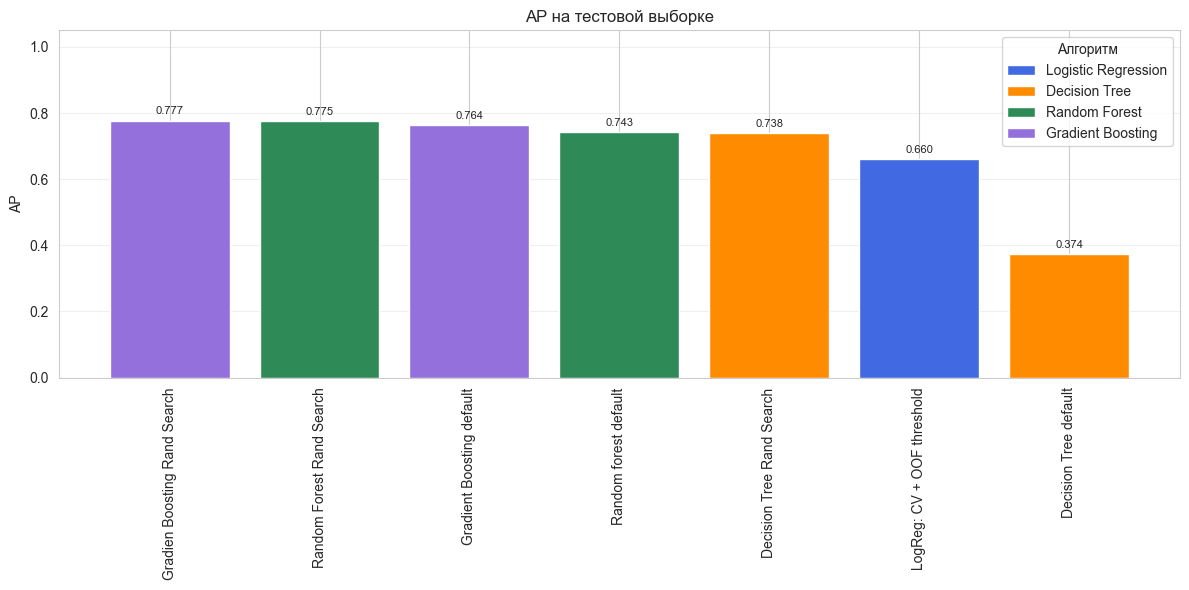

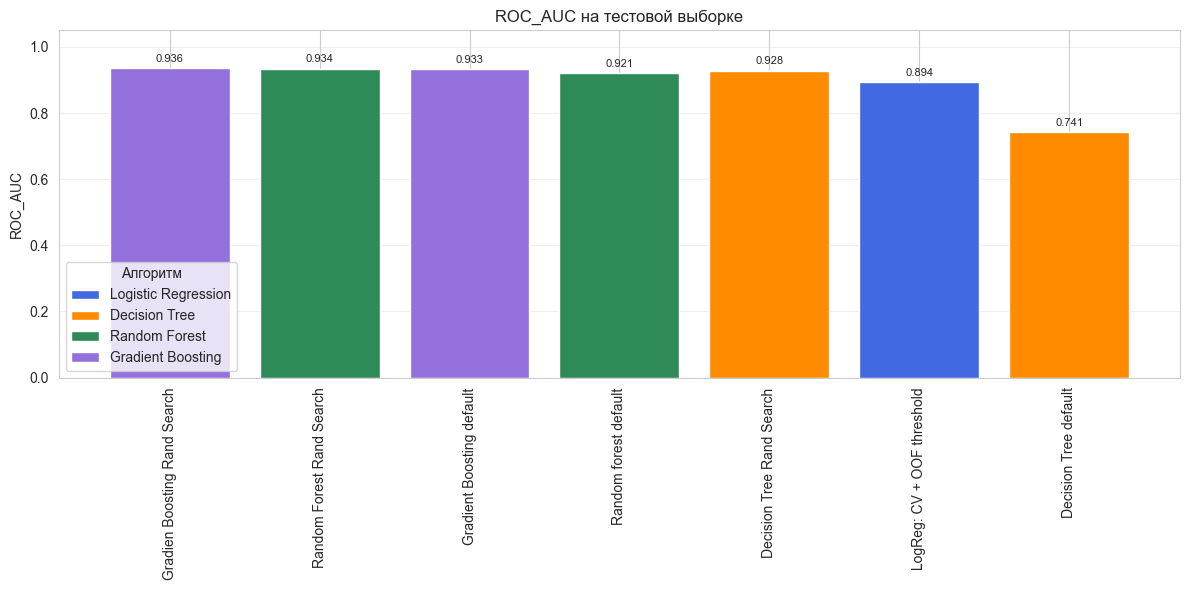

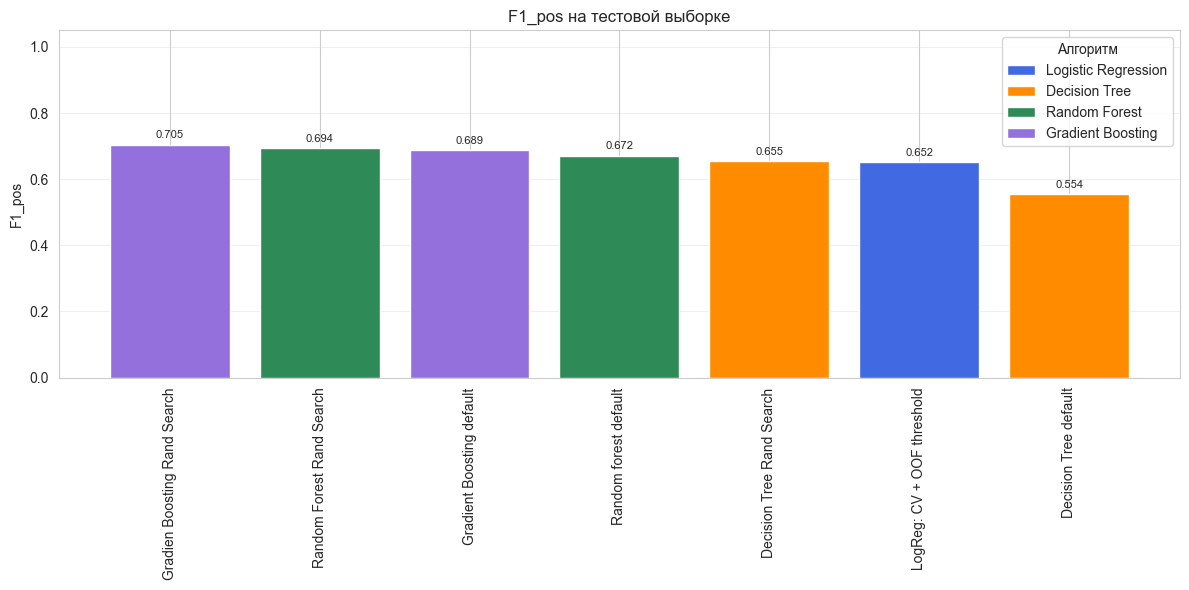

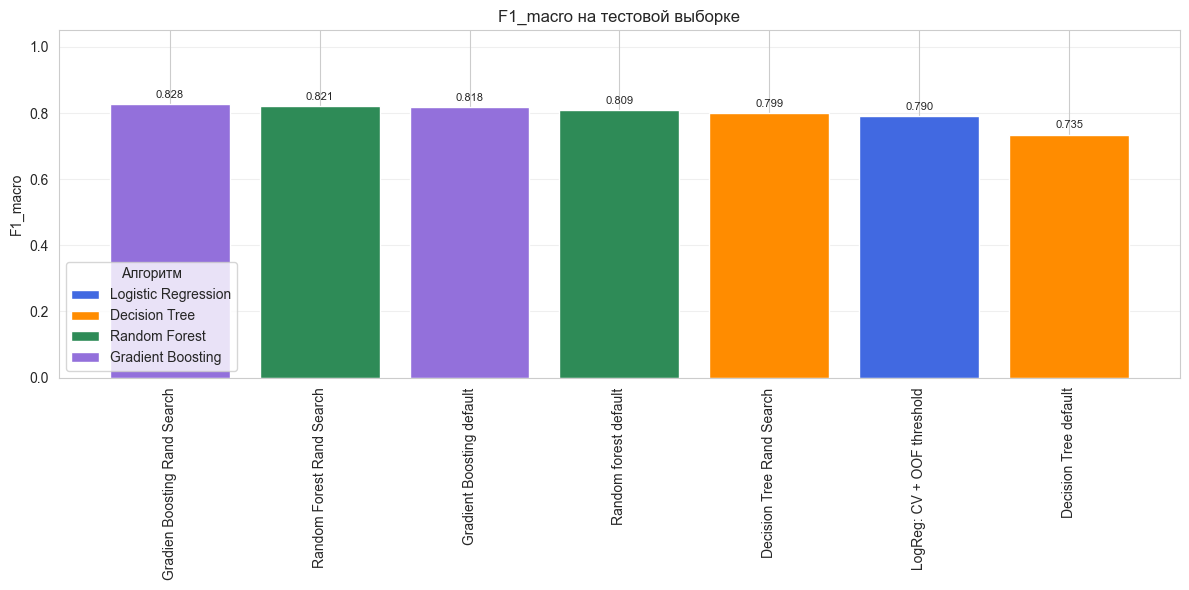

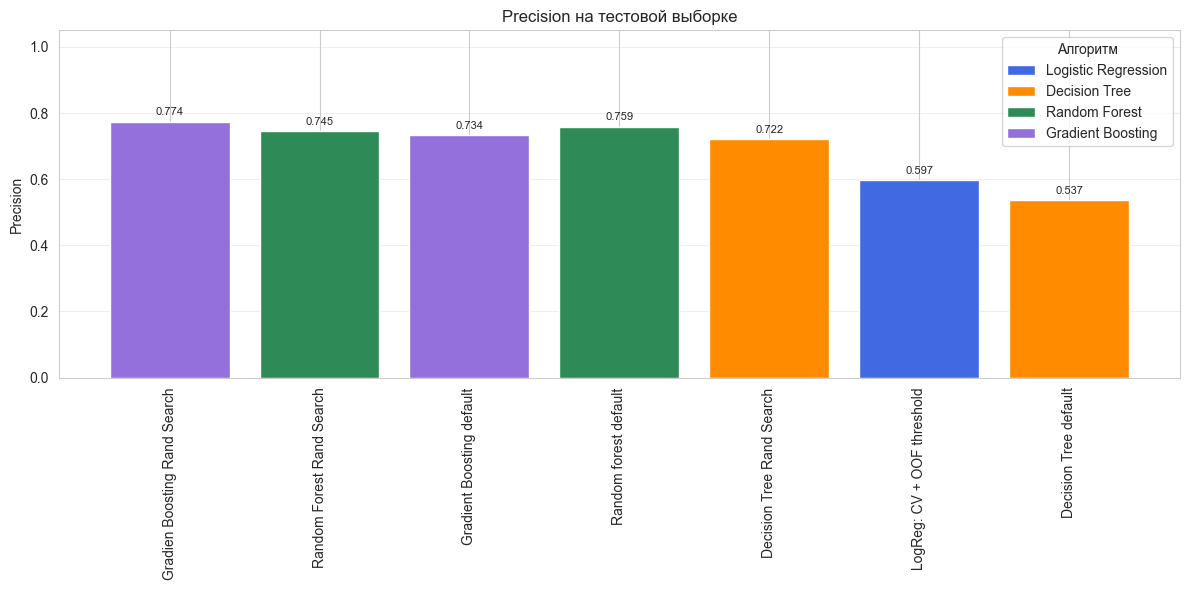

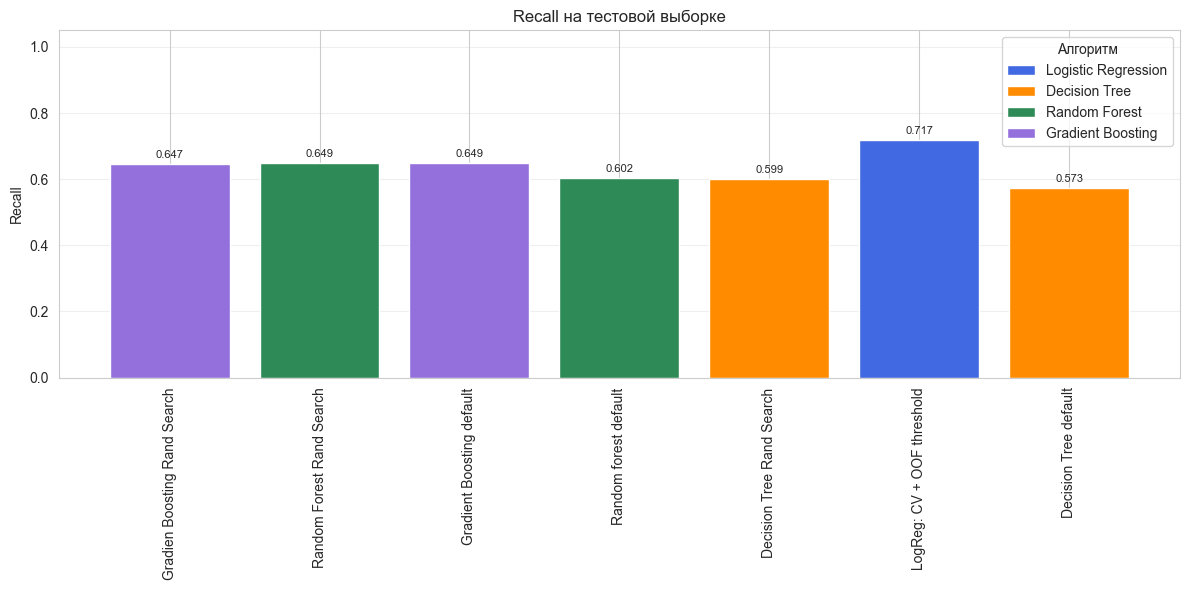

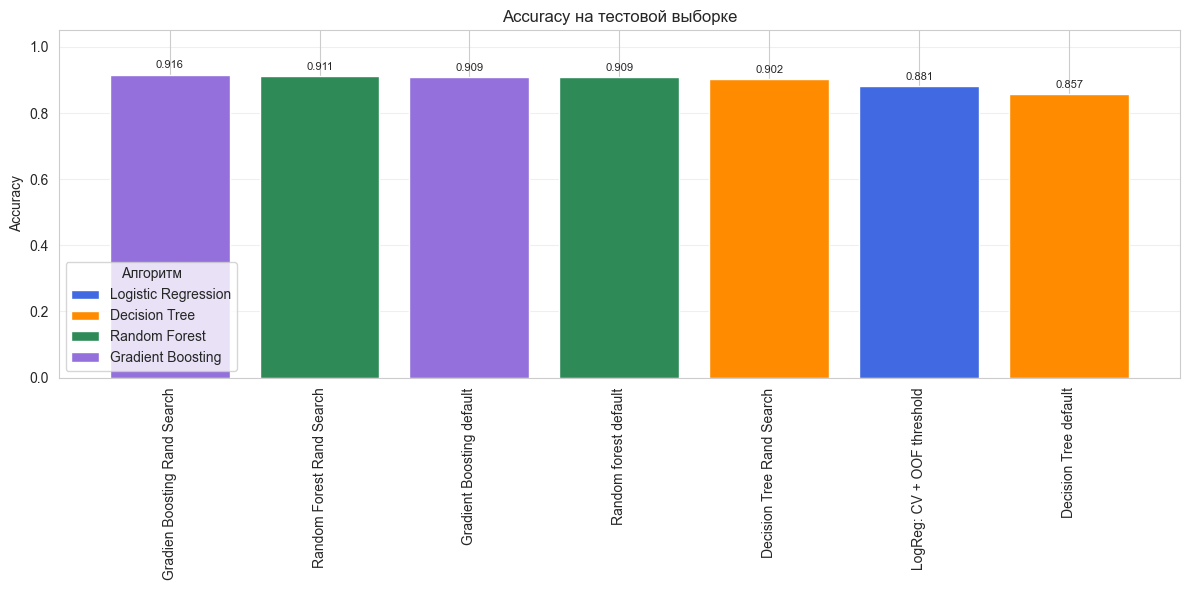

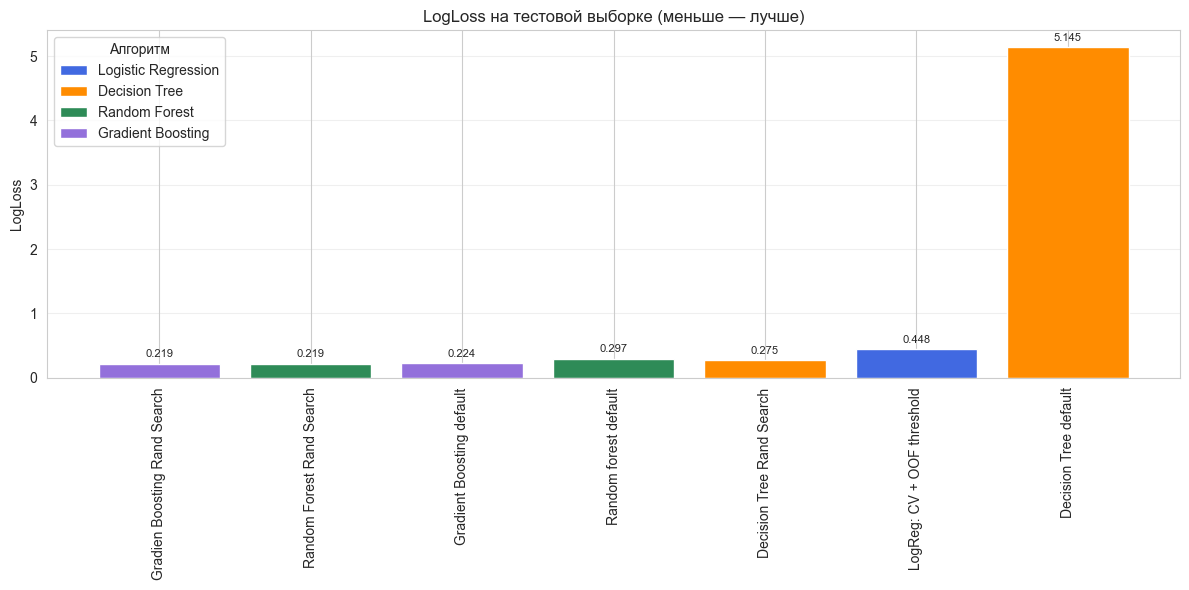

In [129]:
from matplotlib.patches import Patch

metrics_to_plot = [
    "AP", "ROC_AUC", "F1_pos", "F1_macro",
    "Precision", "Recall", "Accuracy", "LogLoss",
]

algorithm_colors = {
    "Logistic Regression": "royalblue",
    "Decision Tree": "darkorange",
    "Random Forest": "seagreen",
    "Gradient Boosting": "mediumpurple",
}

def algorithm_type(model_name):
    name = model_name.lower()

    if "logreg" in name or "logistic" in name:
        return "Logistic Regression"
    if "forest" in name:
        return "Random Forest"
    if "boosting" in name:
        return "Gradient Boosting"
    if "tree" in name:
        return "Decision Tree"

    raise ValueError(f"Неизвестный тип алгоритма: {model_name}")


model_names = test_results.index.tolist()
colors = [
    algorithm_colors[algorithm_type(name)]
    for name in model_names
]

used_algorithms = {
    algorithm_type(name) for name in model_names
}
legend_handles = [
    Patch(facecolor=color, label=algorithm)
    for algorithm, color in algorithm_colors.items()
    if algorithm in used_algorithms
]

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.bar(
        model_names,
        test_results[metric],
        color=colors,
    )

    ax.set_title(
        f"{metric} на тестовой выборке"
        + (" (меньше — лучше)" if metric == "LogLoss" else "")
    )
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", labelrotation=90)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    if metric != "LogLoss":
        ax.set_ylim(0, 1.05)

    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.legend(handles=legend_handles, title="Алгоритм")

    plt.tight_layout()
    plt.show()